Goal: The Goal is to Underastand what Influences the shopping behaviour of people

## Importation and Package Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import datetime
import seaborn as sns
import plotly.express as px
import datetime
import warnings
warnings.filterwarnings('ignore')
from statsmodels.graphics.mosaicplot import mosaic
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
import shap

sns.set(
    {"figure.figsize": (8, 6)},
    style='ticks',
    color_codes=True,
    font_scale=0.8
)
%config InlineBackend.figure_format = 'retina'
PALETTE = 'Set2'
print("All libraries imported successfully.")


All libraries imported successfully.


Import dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
shopping = pd.read_csv("/content/drive/MyDrive/shopping_behavior_updated.csv")

Lets Load the dataset to check what type of figures we will be working with

In [4]:
shopping.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


Now that we can see the features we are working with lets check for completness of the dataset to avoid bias

In [5]:
shopping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

we can see from the output that there are no missing data
now lets explore the data set to check for the relationships of the features.
Using a bar chart i will check the differences between the shopping habit of  male and female shopping.

In [6]:
shopping.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.749949,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716223,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.700000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


Gender
Male      2652
Female    1248
Name: count, dtype: int64


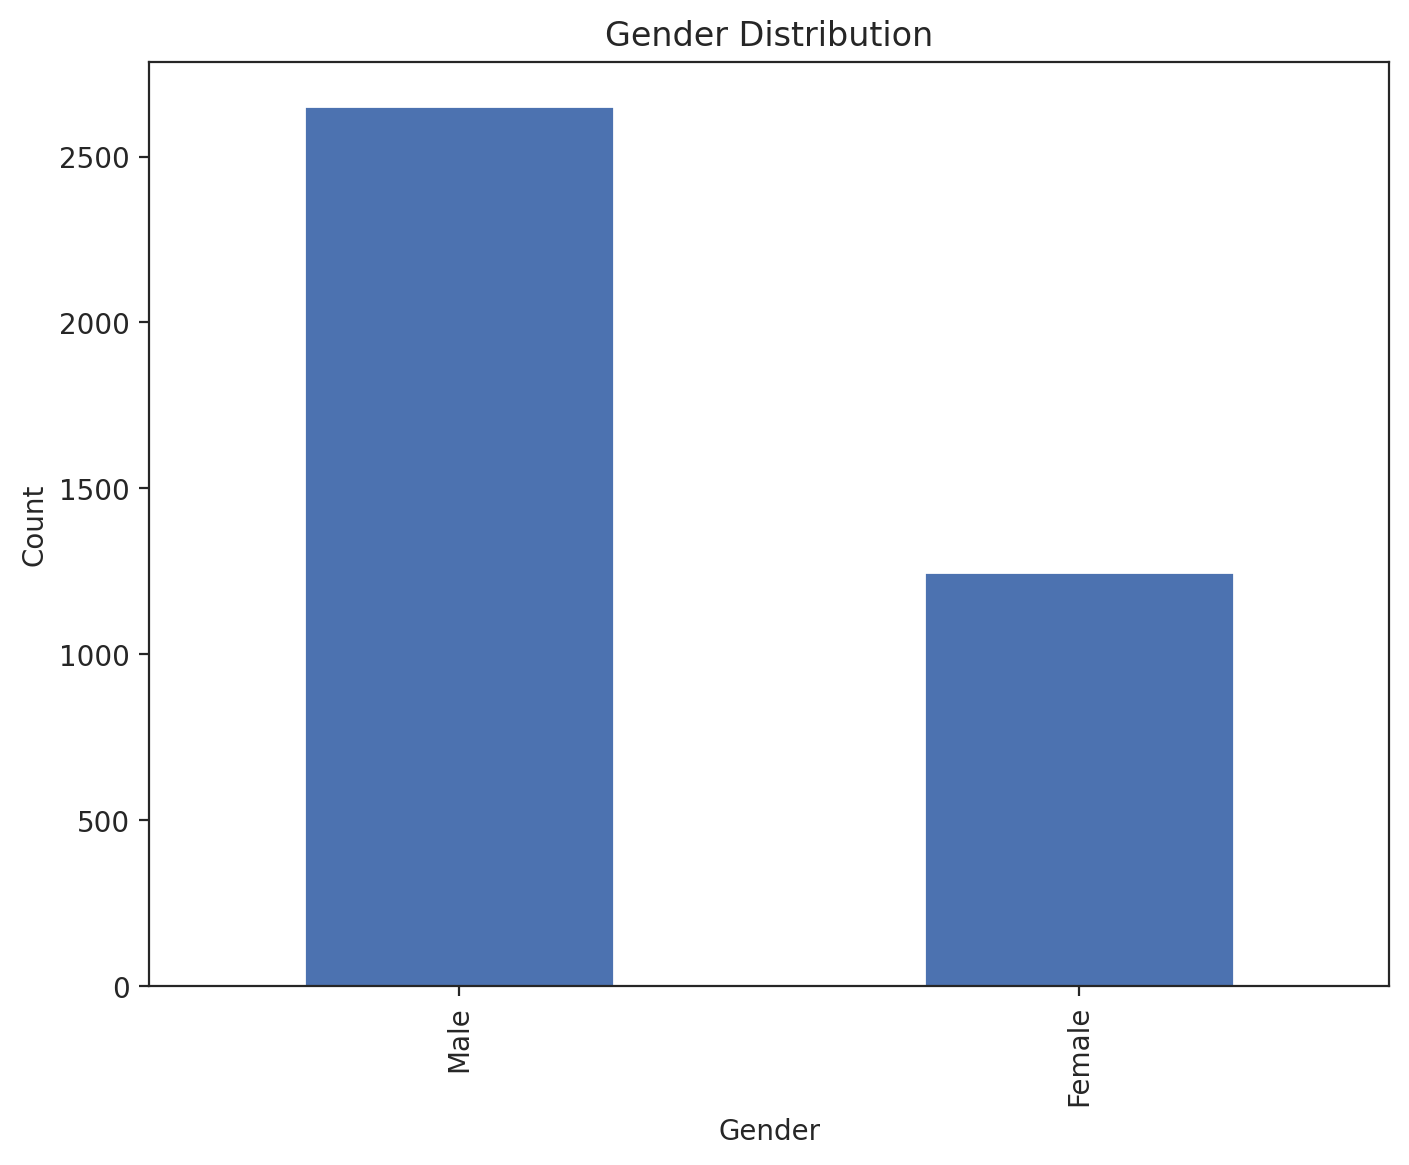

In [7]:
Gender_counts = shopping['Gender'].value_counts()
Gender_counts.plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
print(Gender_counts)

This output shows that there are more Male shoppers than female shoppers. Lets check what is influencng the male gender to shop more. Let check the percentage of male and female shopping based on other features

<Axes: xlabel='Gender'>

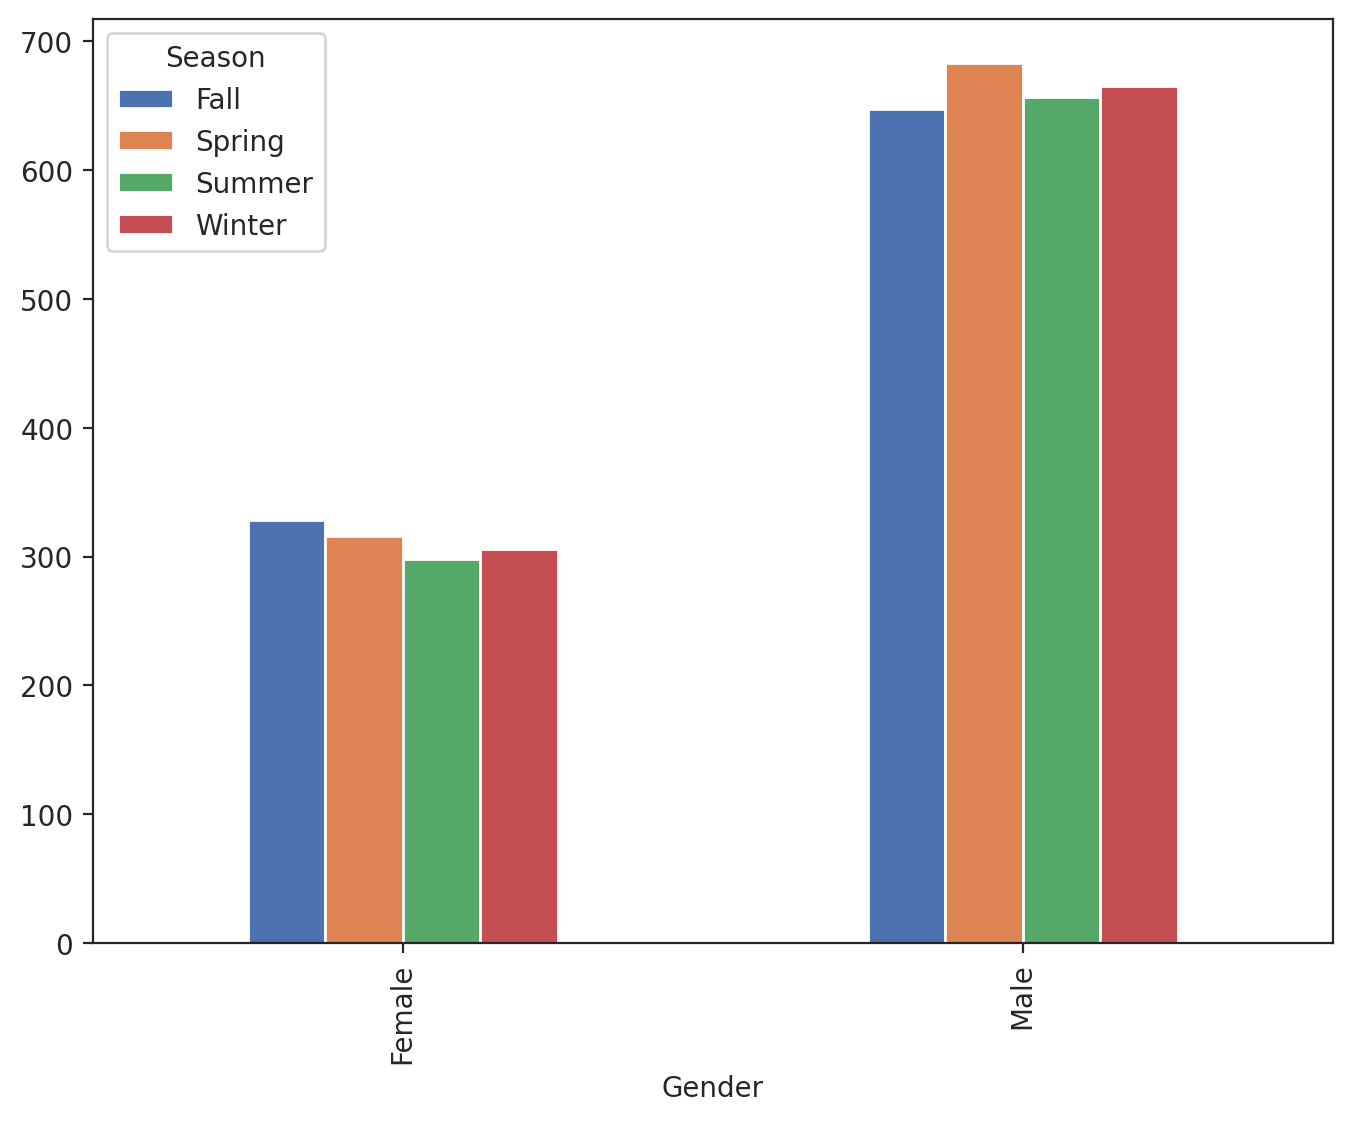

In [8]:
shopping.groupby(["Gender","Season"]).size().unstack().plot(kind="bar")


The output shows that the men shop a lot but averagly shop the most in spring while the females shop more in fall.
Now i will check why they shop more in spring and if there are any influence to it

 Distribution of Key Numeric Variables

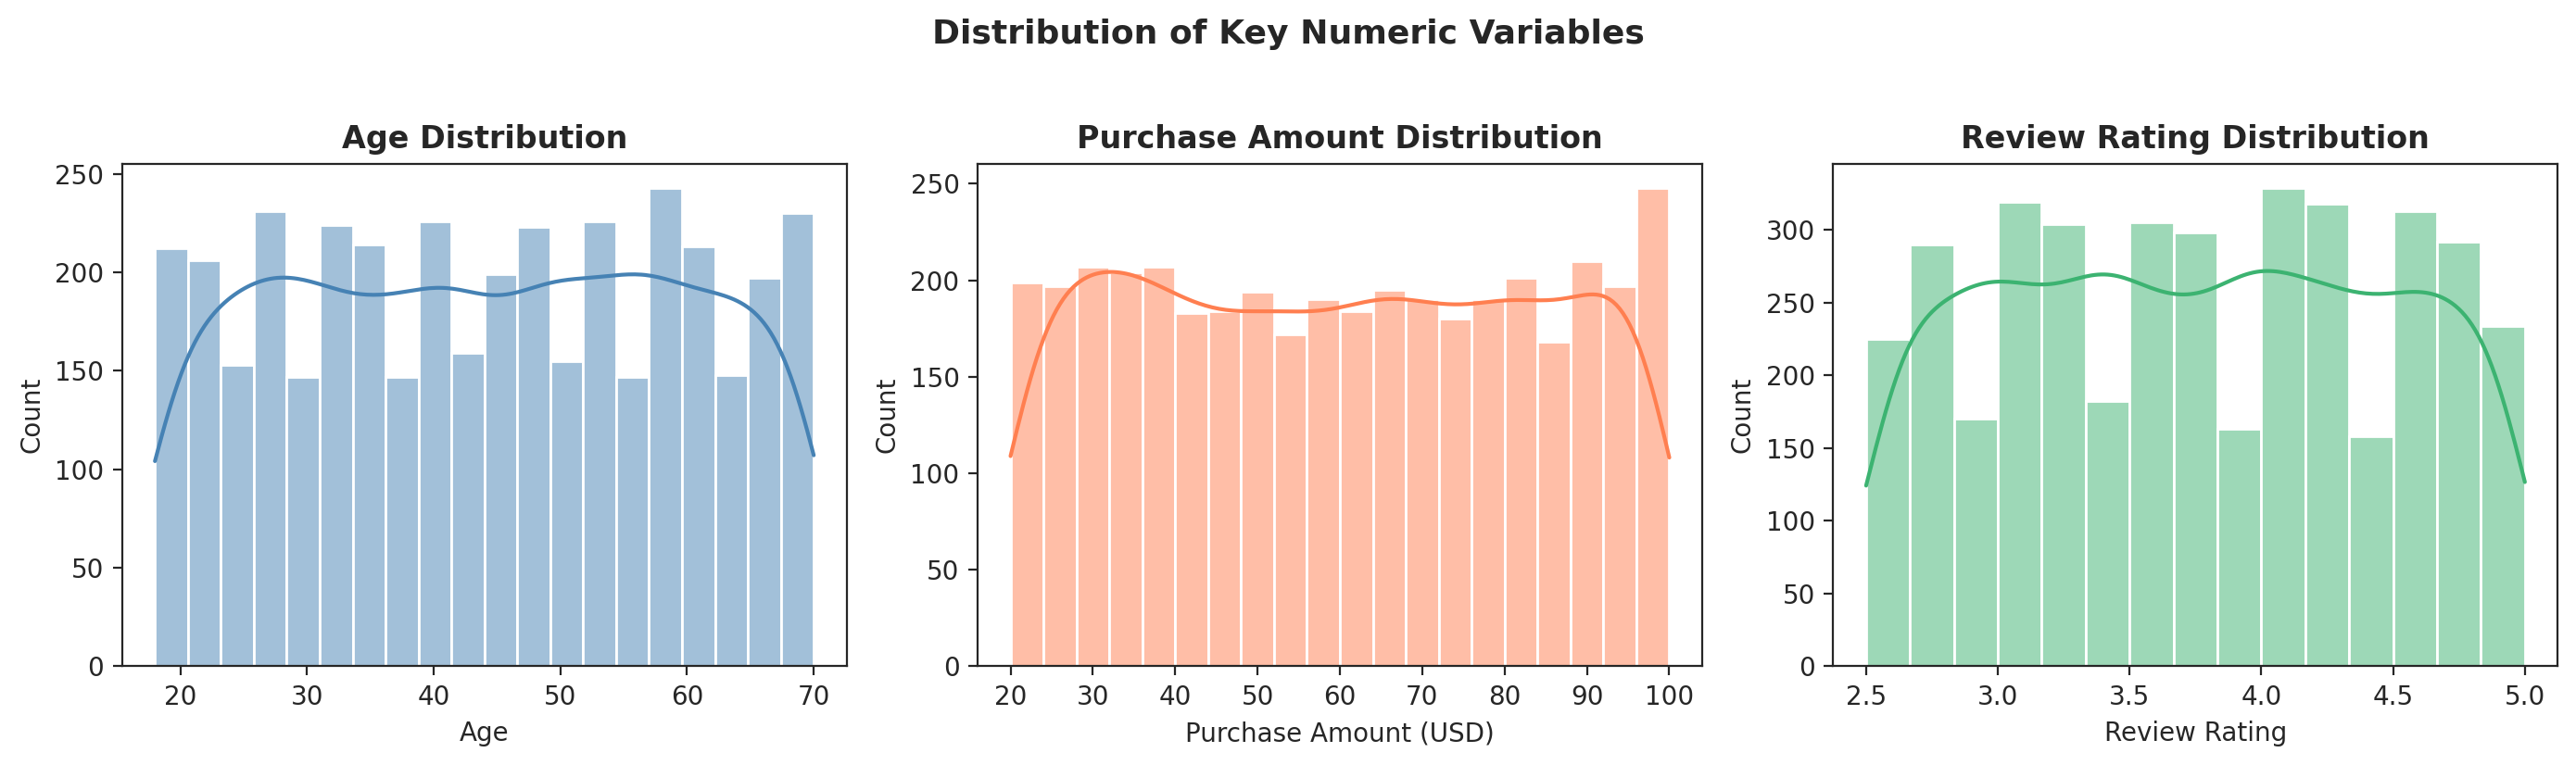

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(shopping['Age'], bins=20, color='steelblue', ax=axes[0], kde=True)
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')

sns.histplot(shopping['Purchase Amount (USD)'], bins=20, color='coral', ax=axes[1], kde=True)
axes[1].set_title('Purchase Amount Distribution', fontweight='bold')
axes[1].set_xlabel('Purchase Amount (USD)')

sns.histplot(shopping['Review Rating'], bins=15, color='mediumseagreen', ax=axes[2], kde=True)
axes[2].set_title('Review Rating Distribution', fontweight='bold')
axes[2].set_xlabel('Review Rating')
plt.suptitle('Distribution of Key Numeric Variables', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Analyze the `shopping` DataFrame to determine which season has the most 'Discount Applied' and 'Promo Code Used' instances, and visualize these findings using bar charts with clear legends.

Group the dataset by 'Season' and count the occurrences where 'Discount Applied' is 'Yes'. Then, determine which season has the highest count of applied discounts.


**Reasoning**:
To identify the season with the most discounts, I will first filter the dataframe to include only items where a discount was applied. Then, I will count the occurrences of each season in this filtered data.



In [10]:
discounted_items = shopping[shopping['Discount Applied'] == 'Yes']
discounted_season_counts = discounted_items['Season'].value_counts()
print(discounted_season_counts)


Season
Spring    440
Summer    423
Winter    417
Fall      397
Name: count, dtype: int64


**Reasoning**:
The previous step successfully calculated the number of discounted items per season. Now, I will identify and explicitly state the season with the highest count of applied discounts from the `discounted_season_counts` series.



In [11]:
most_discounted_season = discounted_season_counts.idxmax()
max_discounts = discounted_season_counts.max()
print(f"The season with the most applied discounts is '{most_discounted_season}' with {max_discounts} discounts.")

The season with the most applied discounts is 'Spring' with 440 discounts.


**Reasoning**:
I have successfully identified the season with the most applied discounts. The next logical step, according to the main task, is to visualize this finding using a bar chart. This visualization will clearly show the distribution of discounts across different seasons.



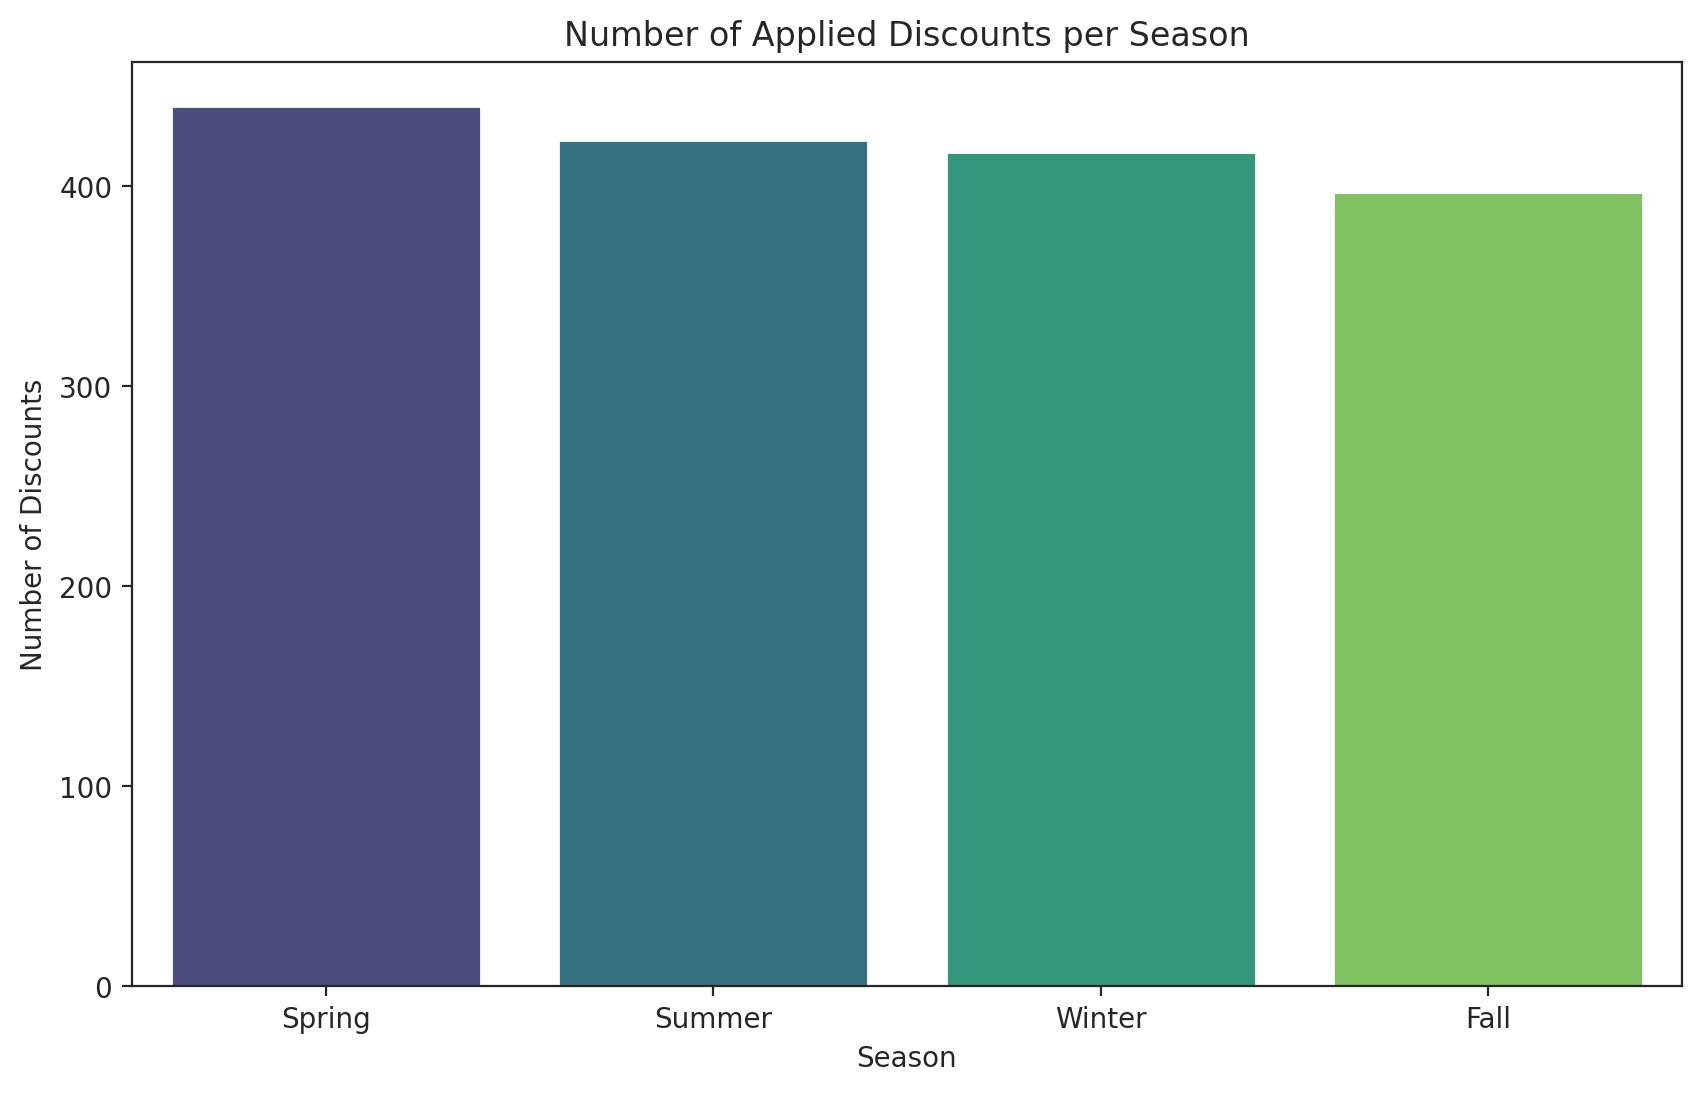

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(x=discounted_season_counts.index, y=discounted_season_counts.values, palette='viridis')
plt.title('Number of Applied Discounts per Season')
plt.xlabel('Season')
plt.ylabel('Number of Discounts')
plt.show()

**Reasoning**:
The subtask requires analyzing both 'Discount Applied' and 'Promo Code Used' instances. I have completed the analysis and visualization for 'Discount Applied'. Now, I need to perform a similar analysis for 'Promo Code Used'. This involves filtering the DataFrame to select only the rows where 'Promo Code Used' is 'Yes' and then counting the occurrences of each unique season in this filtered data.
Now i will check if this discount was applied mostly by the male or the female.



In [13]:
gender_discount_usage = discounted_items.groupby('Gender').size()
print(gender_discount_usage)
gender_usage = shopping.groupby('Gender').size()
print(gender_usage)

Gender
Male    1677
dtype: int64
Gender
Female    1248
Male      2652
dtype: int64


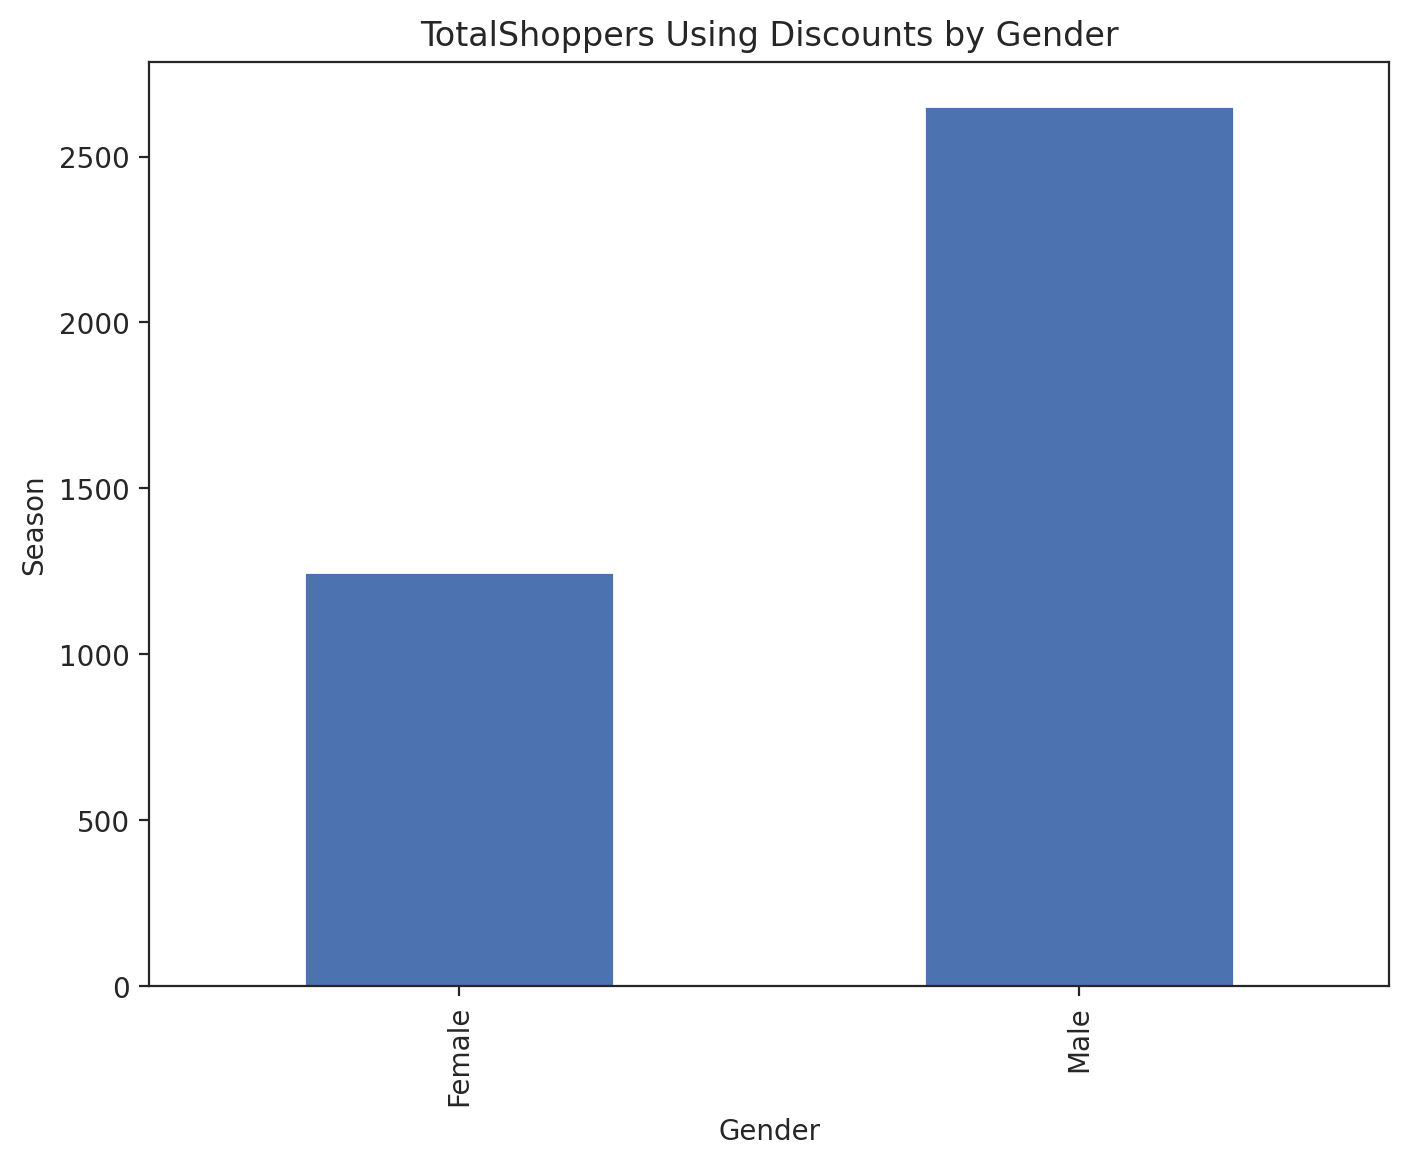

In [14]:
plt.figure()
gender_usage.plot(kind='bar')
plt.title('TotalShoppers Using Discounts by Gender')
plt.xlabel('Gender')
plt.ylabel('Season')
plt.show()

In [15]:
promo_code_items = shopping[shopping['Promo Code Used'] == 'Yes']
promo_code_season_counts = promo_code_items['Season'].value_counts()
print(promo_code_season_counts)

Season
Spring    440
Summer    423
Winter    417
Fall      397
Name: count, dtype: int64


Because the promo code result and that of the discount code which means they are someworth related to each other. this means that every time a discount is used it can also be said that a promo code has been used and vias versa. therefore to deal with ths i will be dropping  the promo code.

In [16]:
shopping = shopping.drop('Promo Code Used', axis=1)

In [17]:
shopping.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually


To check for the correlation i would be grouping the dataset features into their different categories

In [18]:
quantitative_features = shopping.select_dtypes(include=['int64', 'float64'])
print(quantitative_features)
categorical_features = shopping.select_dtypes(include=['object'])
print(categorical_features)

      Customer ID  Age  Purchase Amount (USD)  Review Rating  \
0               1   55                     53            3.1   
1               2   19                     64            3.1   
2               3   50                     73            3.1   
3               4   21                     90            3.5   
4               5   45                     49            2.7   
...           ...  ...                    ...            ...   
3895         3896   40                     28            4.2   
3896         3897   52                     49            4.5   
3897         3898   46                     33            2.9   
3898         3899   44                     77            3.8   
3899         3900   52                     81            3.1   

      Previous Purchases  
0                     14  
1                      2  
2                     23  
3                     49  
4                     31  
...                  ...  
3895                  32  
3896           

Quantitative - Quantitative

Let us check the correlation between the age and other features if there is an influence in the behaviour based on age.

Text(0.5, 1.0, 'Correlation Matrix')

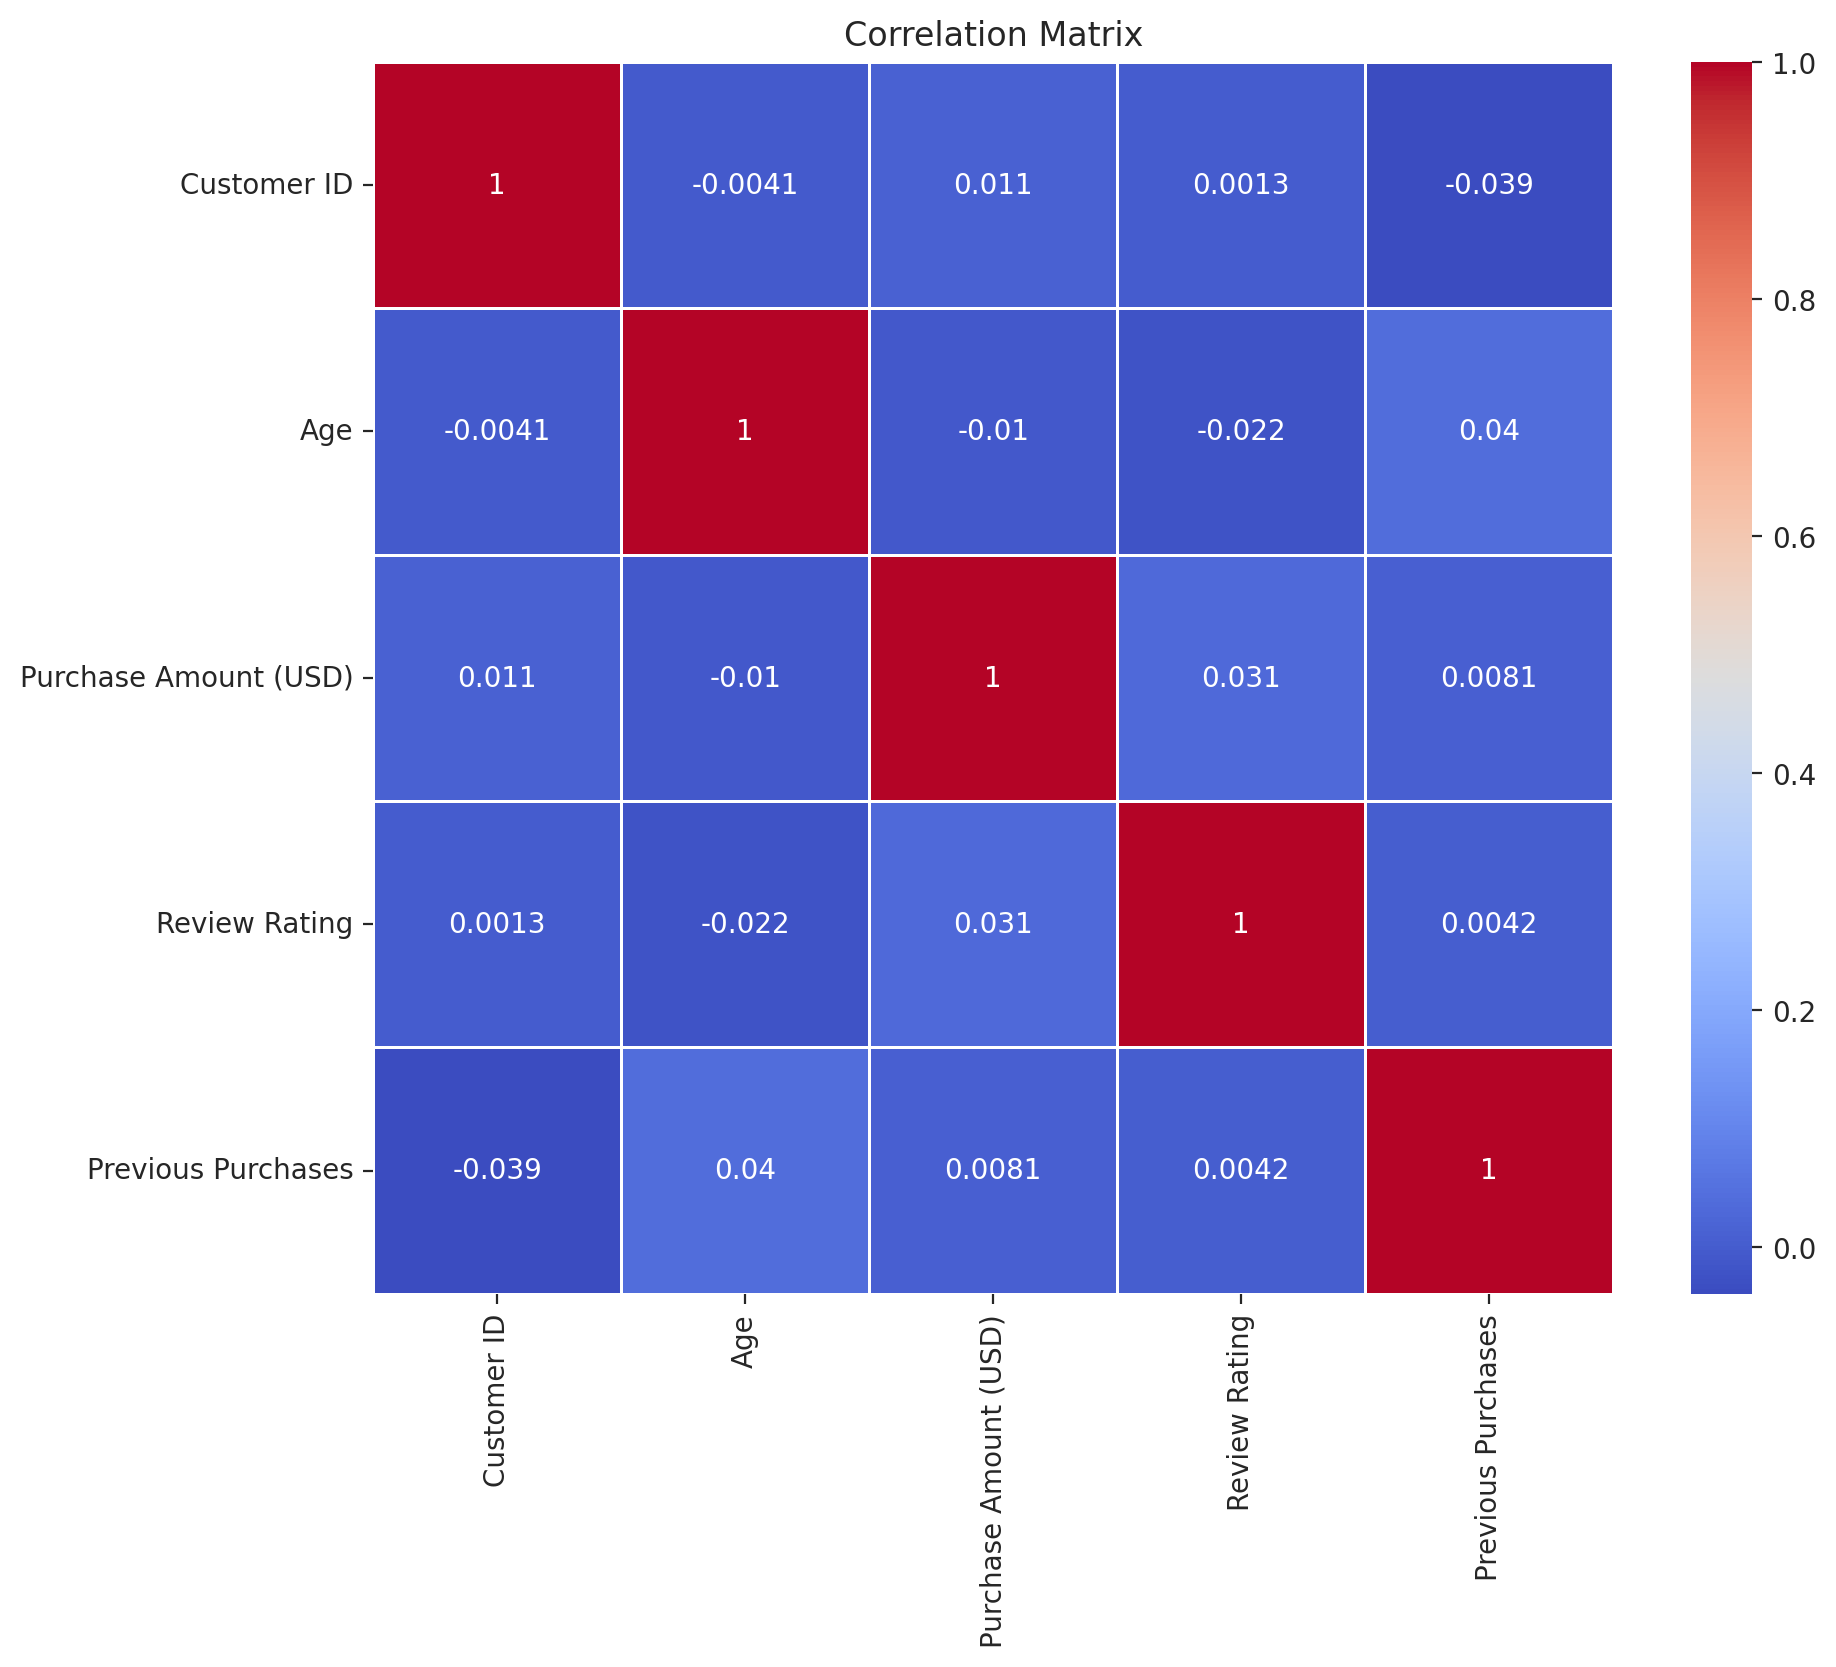

In [19]:
features = quantitative_features.columns
correlation_matrix = shopping[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')


Demographics: Category and Gender

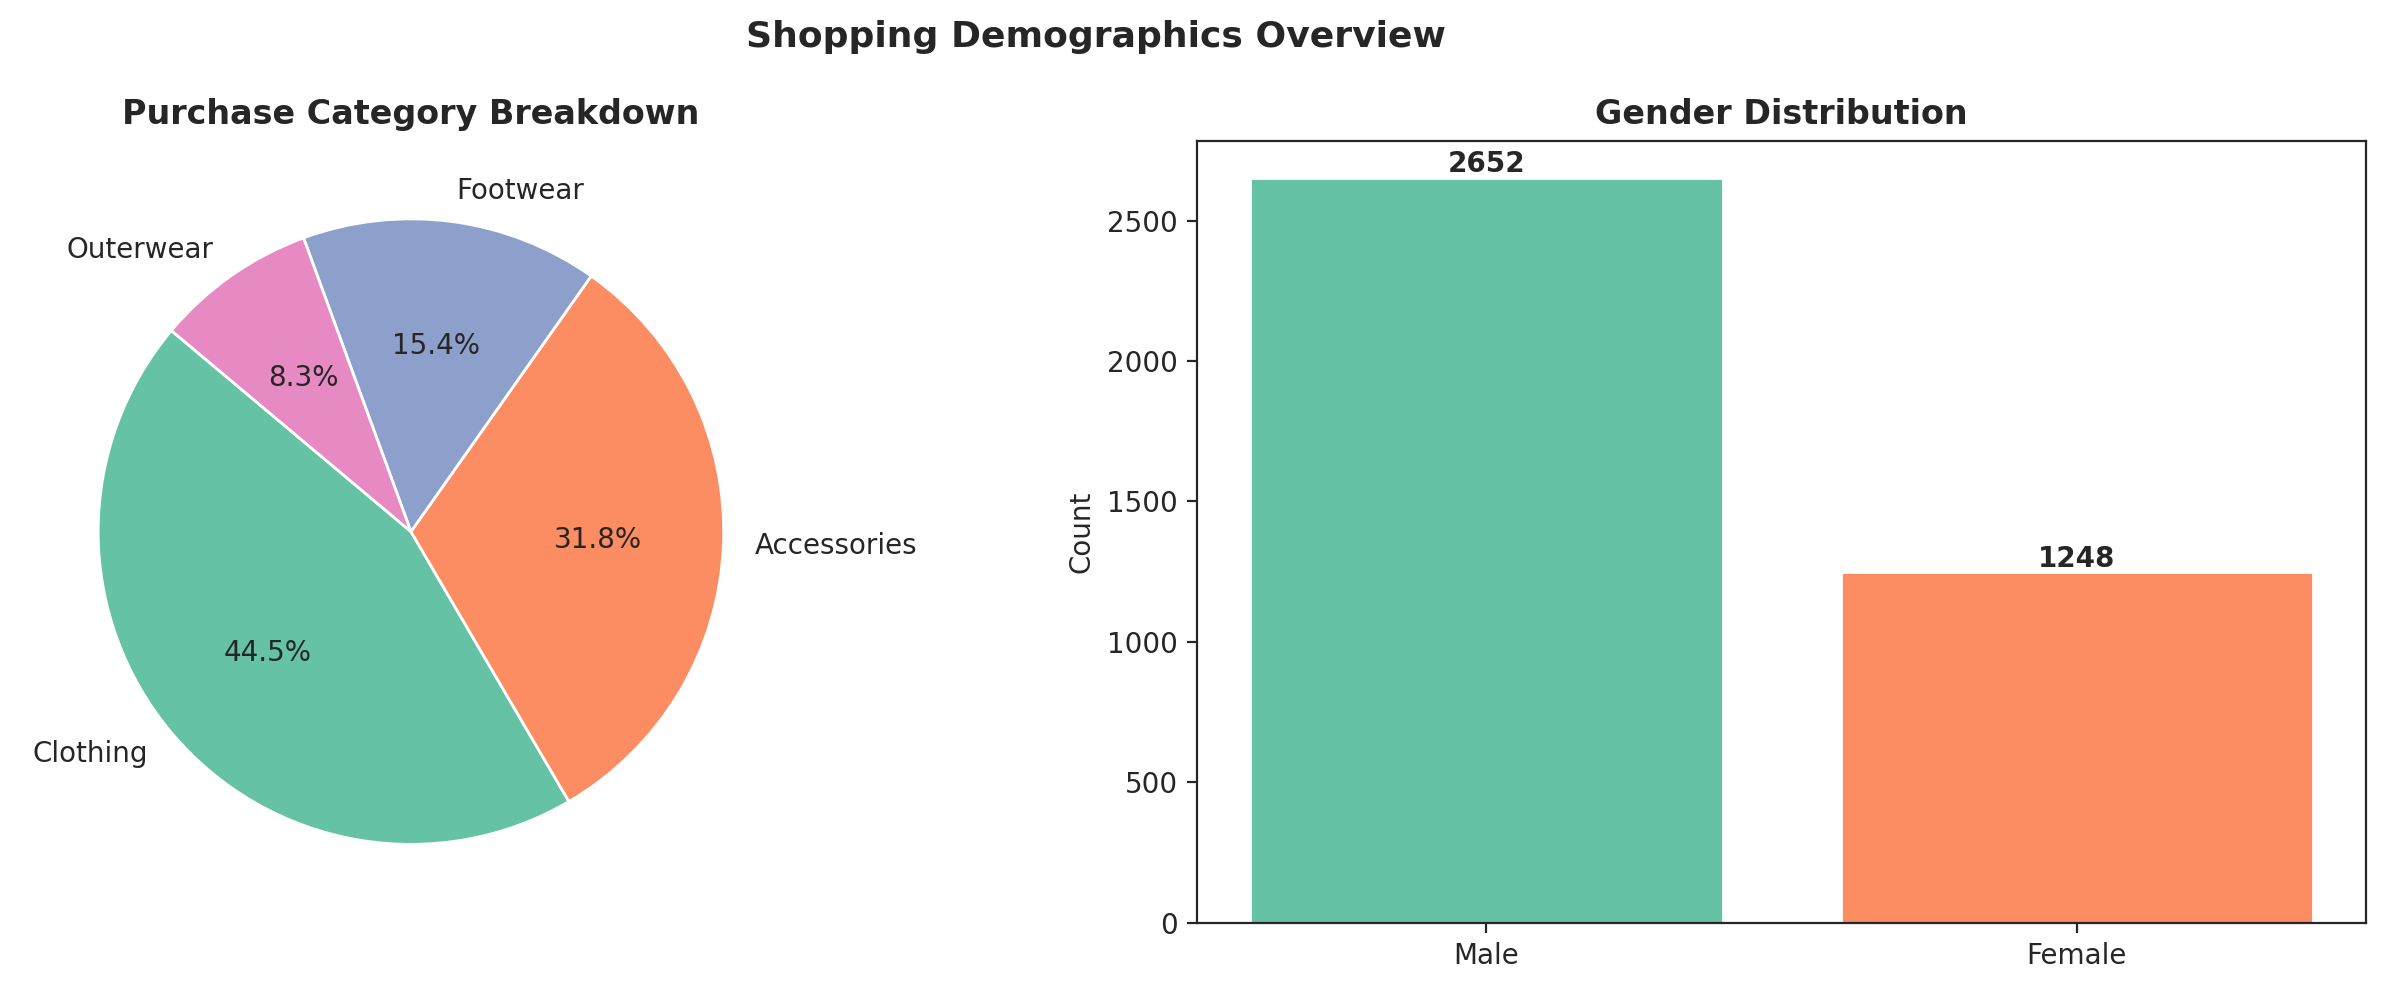

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cat_counts = shopping ['Category'].value_counts()
axes[0].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette(PALETTE, len(cat_counts)), startangle=140)
axes[0].set_title('Purchase Category Breakdown', fontweight='bold')

gen_counts = shopping['Gender'].value_counts()
axes[1].bar(gen_counts.index, gen_counts.values,
            color=sns.color_palette(PALETTE, 2), edgecolor='white')
axes[1].set_title('Gender Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(gen_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.suptitle('Shopping Demographics Overview', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


Seasonal Shopping Patterns

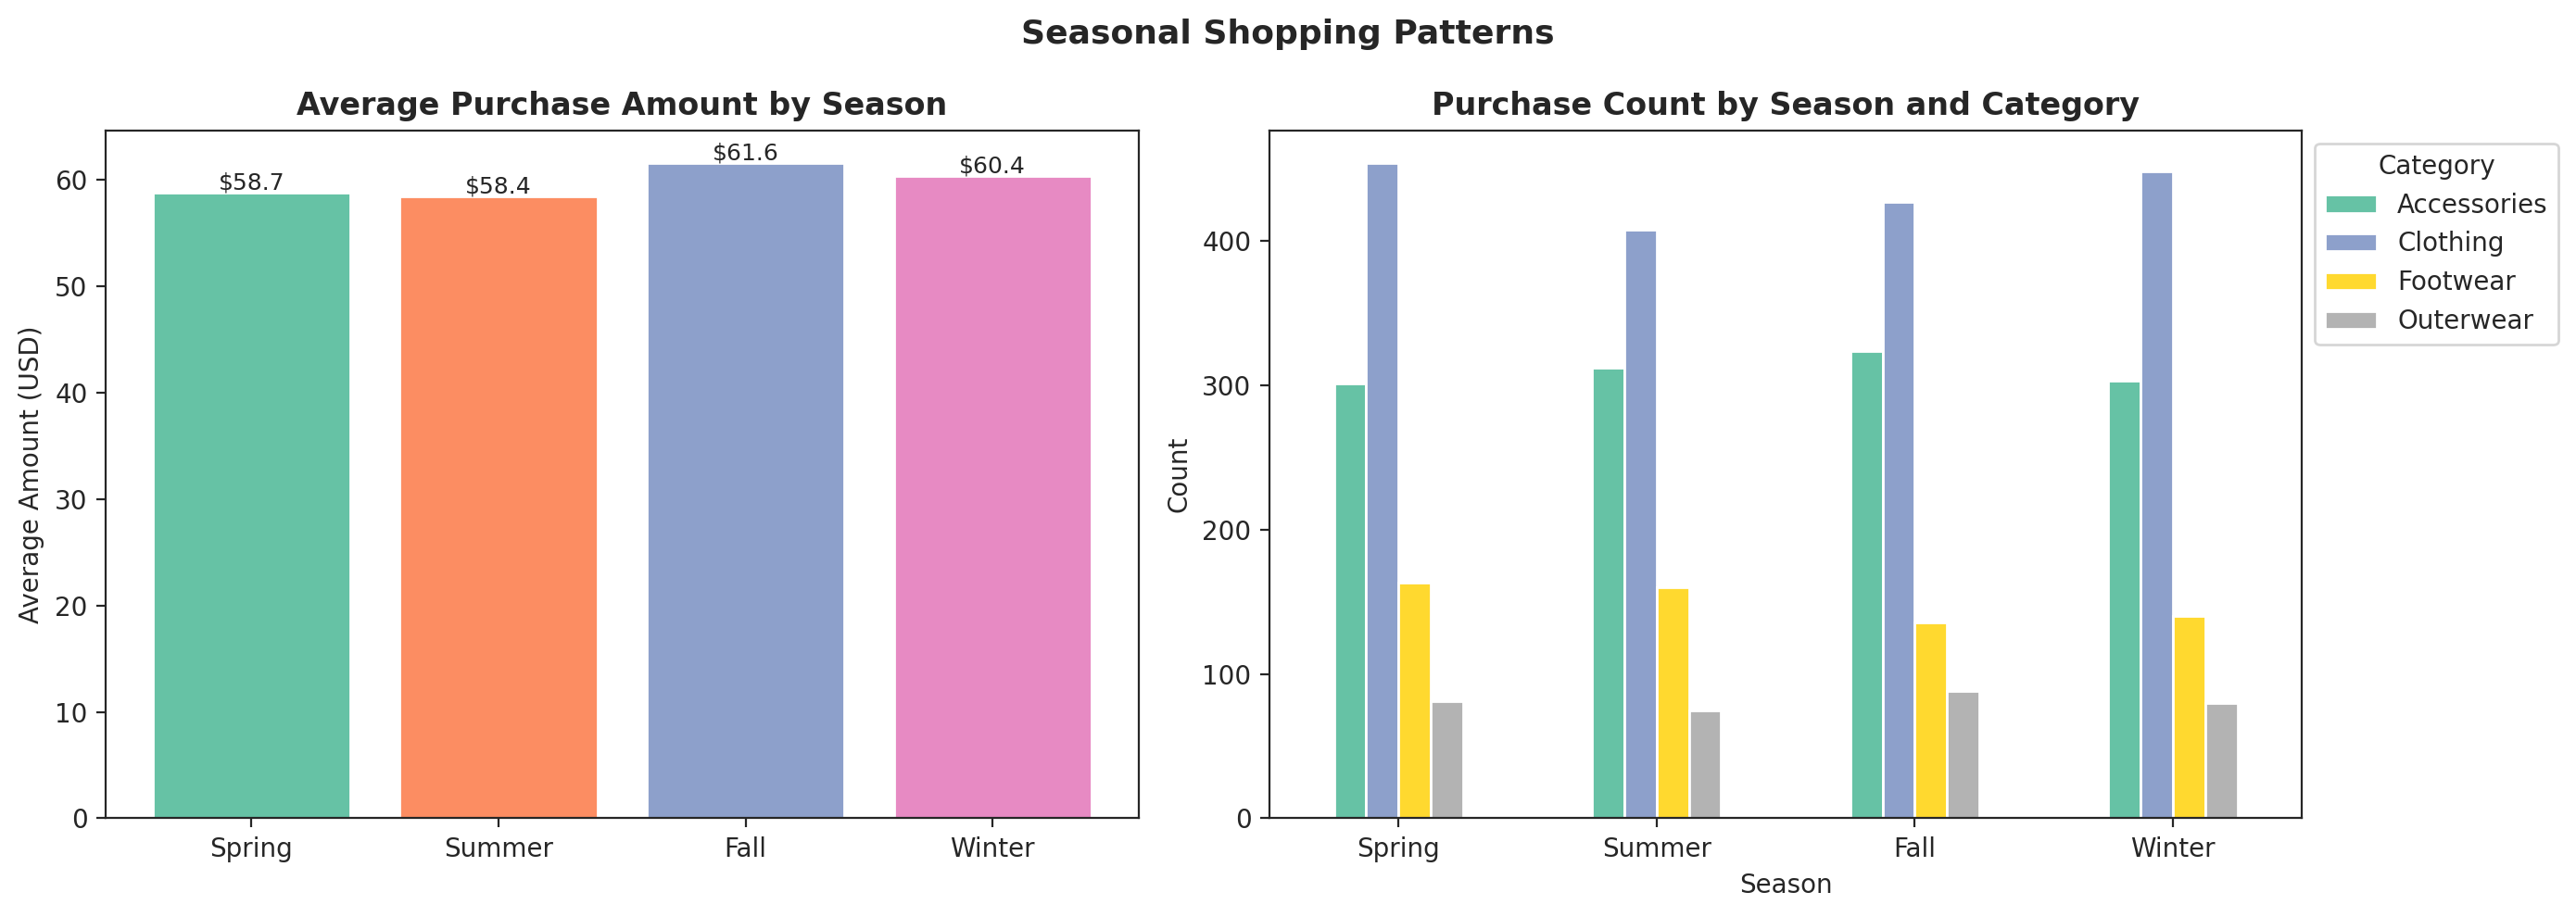

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
season_avg = shopping.groupby('Season')['Purchase Amount (USD)'].mean().reindex(['Spring','Summer','Fall','Winter'])
axes[0].bar(season_avg.index, season_avg.values,
            color=sns.color_palette(PALETTE, 4), edgecolor='white')
axes[0].set_title('Average Purchase Amount by Season', fontweight='bold')
axes[0].set_ylabel('Average Amount (USD)')
for i, v in enumerate(season_avg.values):
    axes[0].text(i, v + 0.3, f'${v:.1f}', ha='center', fontsize=9)

season_cat = shopping.groupby(['Season','Category']).size().unstack(fill_value=0)
season_cat = season_cat.reindex(['Spring','Summer','Fall','Winter'])
season_cat.plot(kind='bar', ax=axes[1], colormap=PALETTE, edgecolor='white', rot=0)
axes[1].set_title('Purchase Count by Season and Category', fontweight='bold')
axes[1].set_xlabel('Season'); axes[1].set_ylabel('Count')
axes[1].legend(title='Category', bbox_to_anchor=(1, 1))
plt.suptitle('Seasonal Shopping Patterns', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


Impact of Discounts and Promo Codes

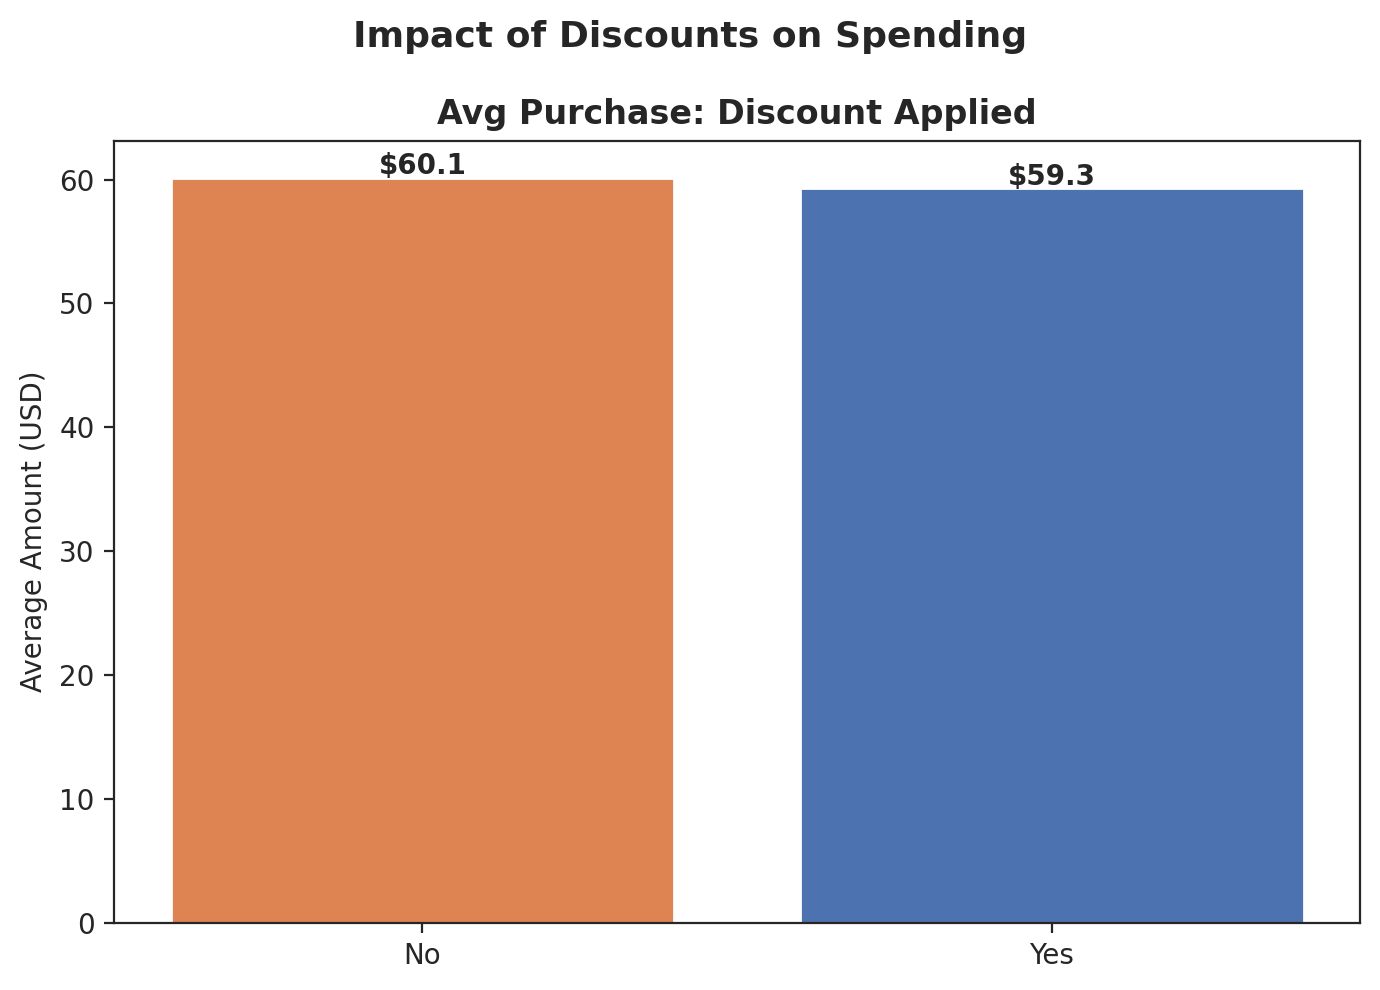

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
disc_avg = shopping.groupby('Discount Applied')['Purchase Amount (USD)'].mean()
ax.bar(disc_avg.index, disc_avg.values, color=['#DD8452','#4C72B0'], edgecolor='white')
ax.set_title('Avg Purchase: Discount Applied', fontweight='bold')
ax.set_ylabel('Average Amount (USD)')
for i, v in enumerate(disc_avg.values):
    ax.text(i, v + 0.3, f'${v:.1f}', ha='center', fontweight='bold')
plt.suptitle('Impact of Discounts on Spending', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

Subscription Status and Customer Behaviour

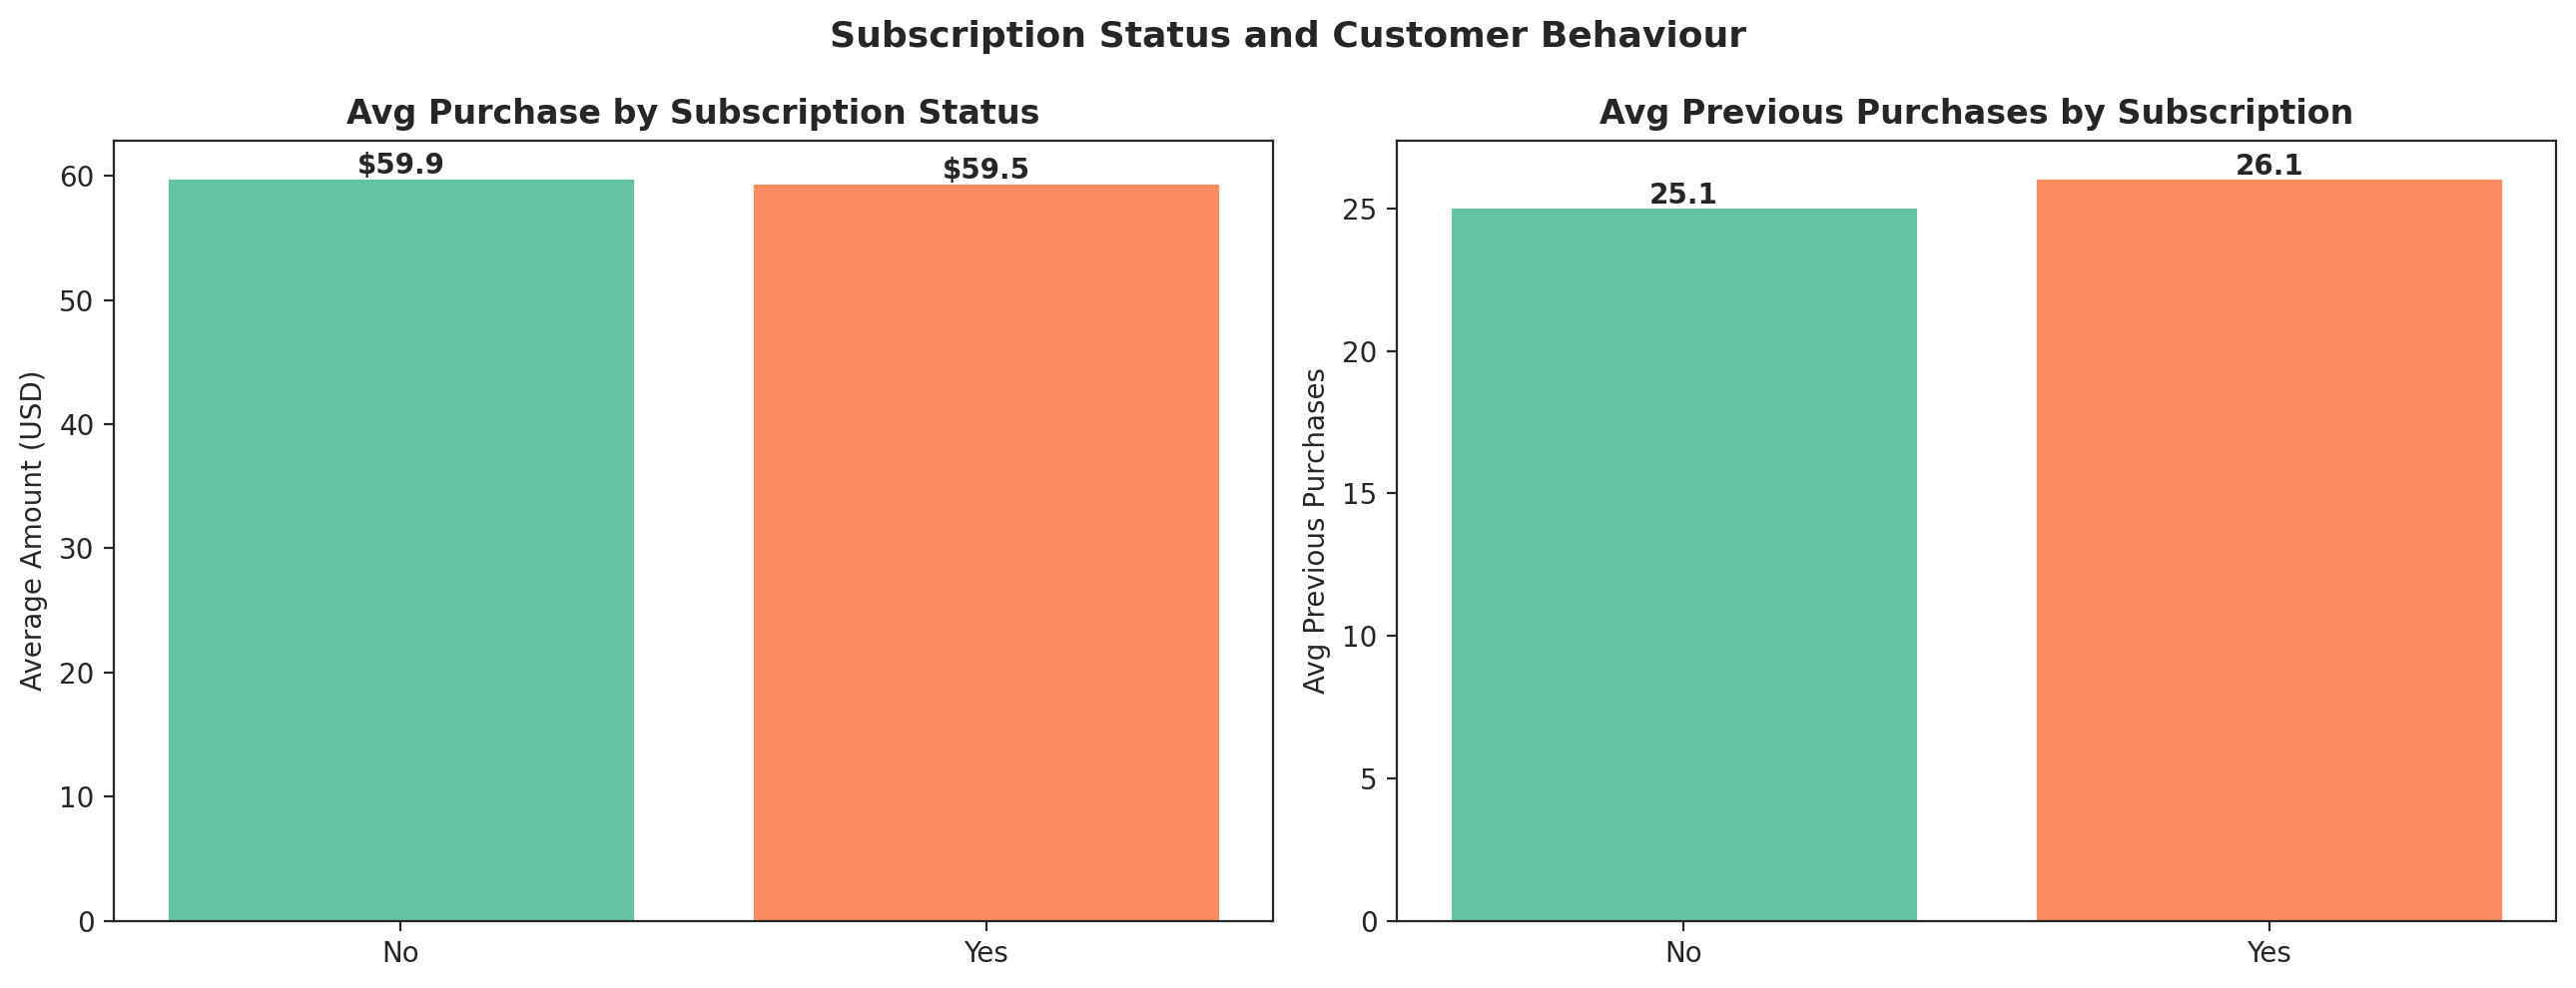

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sub_avg = shopping.groupby('Subscription Status')['Purchase Amount (USD)'].mean()
axes[0].bar(sub_avg.index, sub_avg.values,
            color=sns.color_palette(PALETTE, 2), edgecolor='white')
axes[0].set_title('Avg Purchase by Subscription Status', fontweight='bold')
axes[0].set_ylabel('Average Amount (USD)')
for i, v in enumerate(sub_avg.values):
    axes[0].text(i, v + 0.3, f'${v:.1f}', ha='center', fontweight='bold')

sub_prev = shopping.groupby('Subscription Status')['Previous Purchases'].mean()
axes[1].bar(sub_prev.index, sub_prev.values,
            color=sns.color_palette(PALETTE, 2), edgecolor='white')
axes[1].set_title('Avg Previous Purchases by Subscription', fontweight='bold')
axes[1].set_ylabel('Avg Previous Purchases')
for i, v in enumerate(sub_prev.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')
plt.suptitle('Subscription Status and Customer Behaviour', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

Payment Method and Shipping Preferences

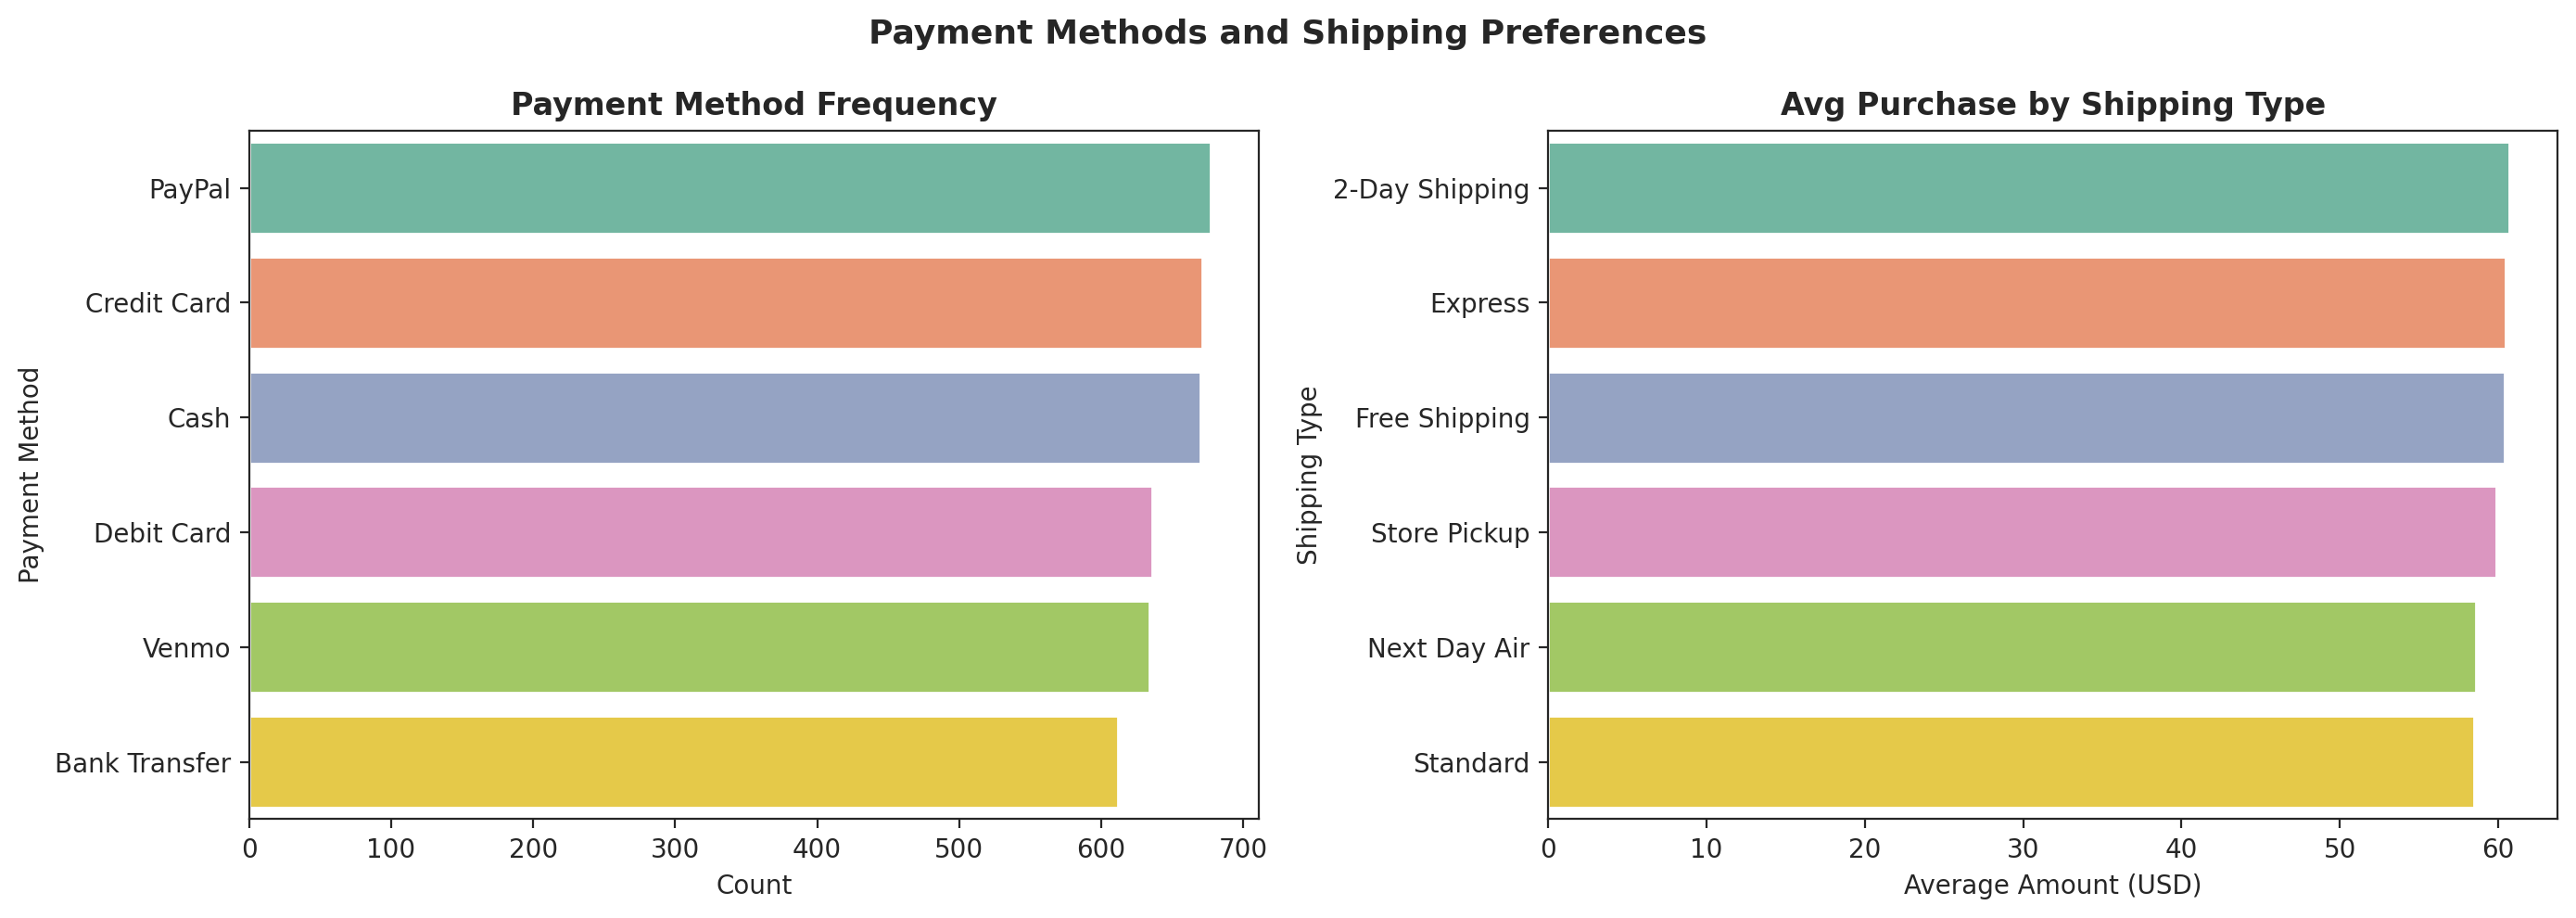

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pay_counts = shopping['Payment Method'].value_counts()
sns.barplot(x=pay_counts.values, y=pay_counts.index, palette=PALETTE, ax=axes[0])
axes[0].set_title('Payment Method Frequency', fontweight='bold')
axes[0].set_xlabel('Count')

ship_avg = shopping.groupby('Shipping Type')['Purchase Amount (USD)'].mean().sort_values(ascending=False)
sns.barplot(x=ship_avg.values, y=ship_avg.index, palette=PALETTE, ax=axes[1])
axes[1].set_title('Avg Purchase by Shipping Type', fontweight='bold')
axes[1].set_xlabel('Average Amount (USD)')
plt.suptitle('Payment Methods and Shipping Preferences', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


Age vs Purchase Amount

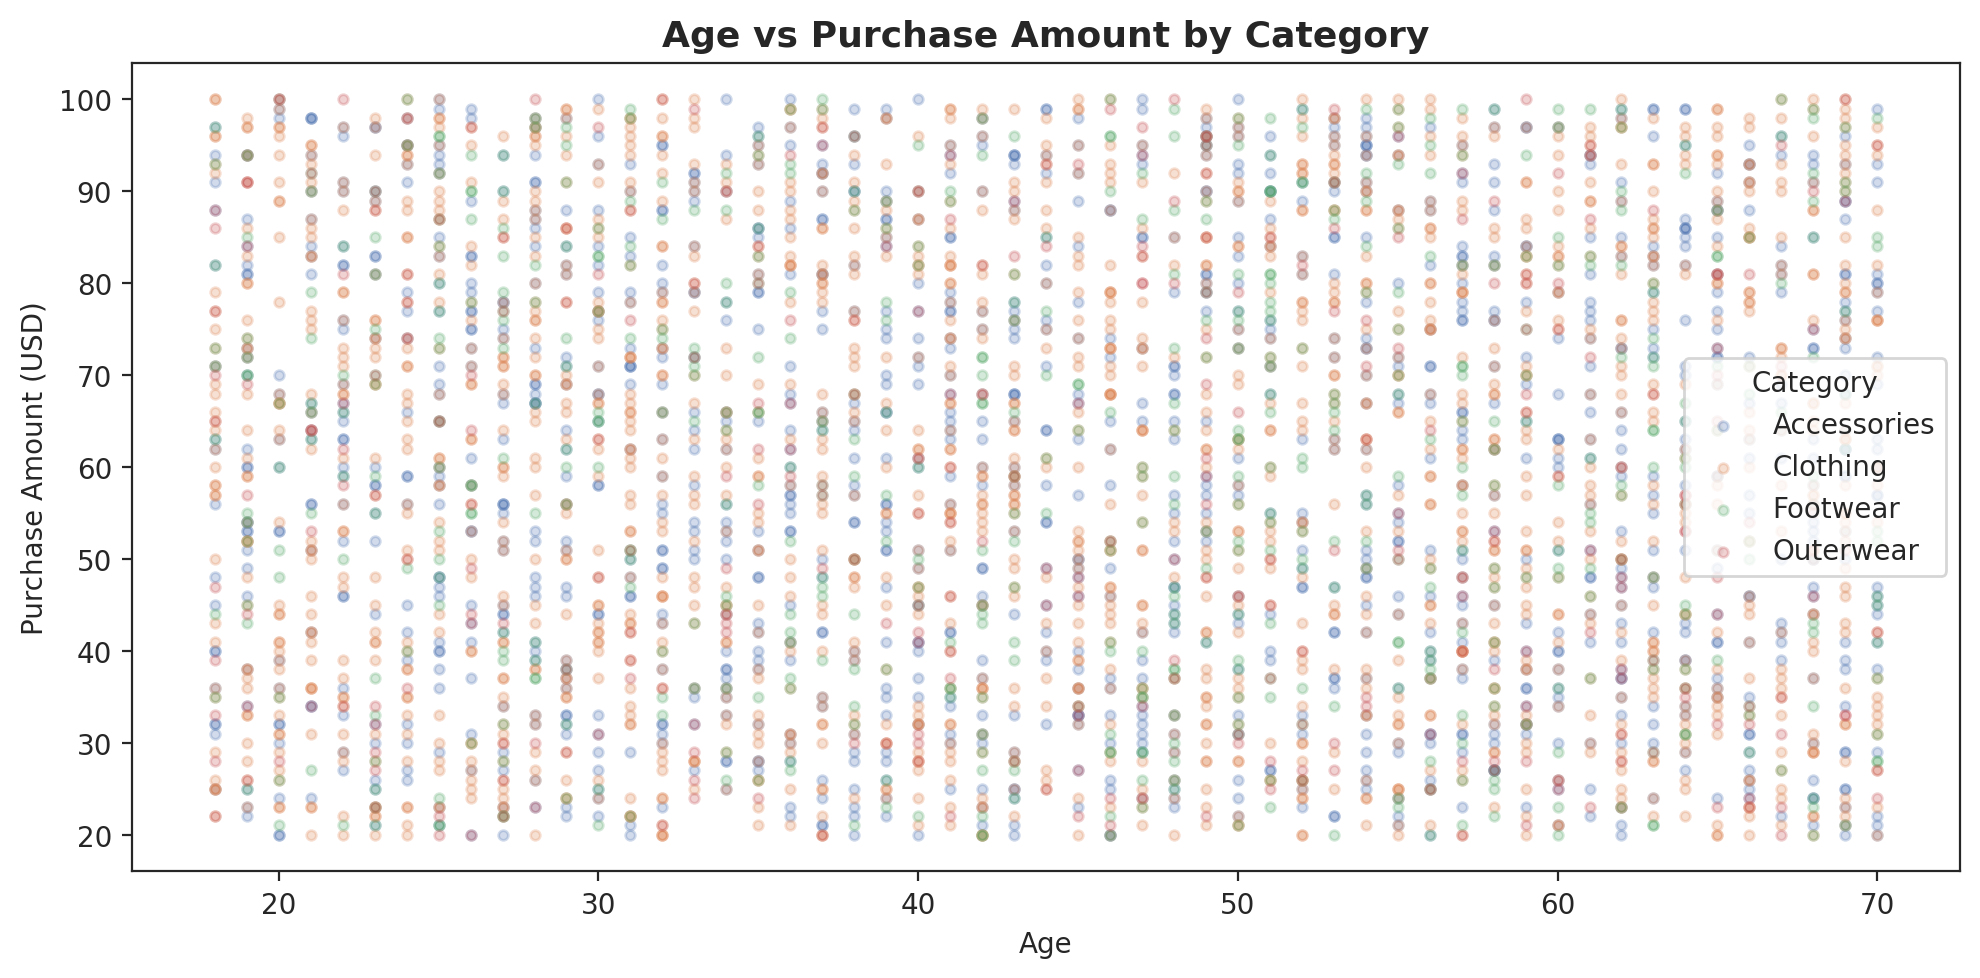

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
for cat, grp in shopping.groupby('Category'):
    ax.scatter(grp['Age'], grp['Purchase Amount (USD)'],
               alpha=0.25, s=12, label=cat)
ax.set_title('Age vs Purchase Amount by Category', fontweight='bold', fontsize=13)
ax.set_xlabel('Age'); ax.set_ylabel('Purchase Amount (USD)')
ax.legend(title='Category')
plt.tight_layout(); plt.show()

Frequency of Purchases

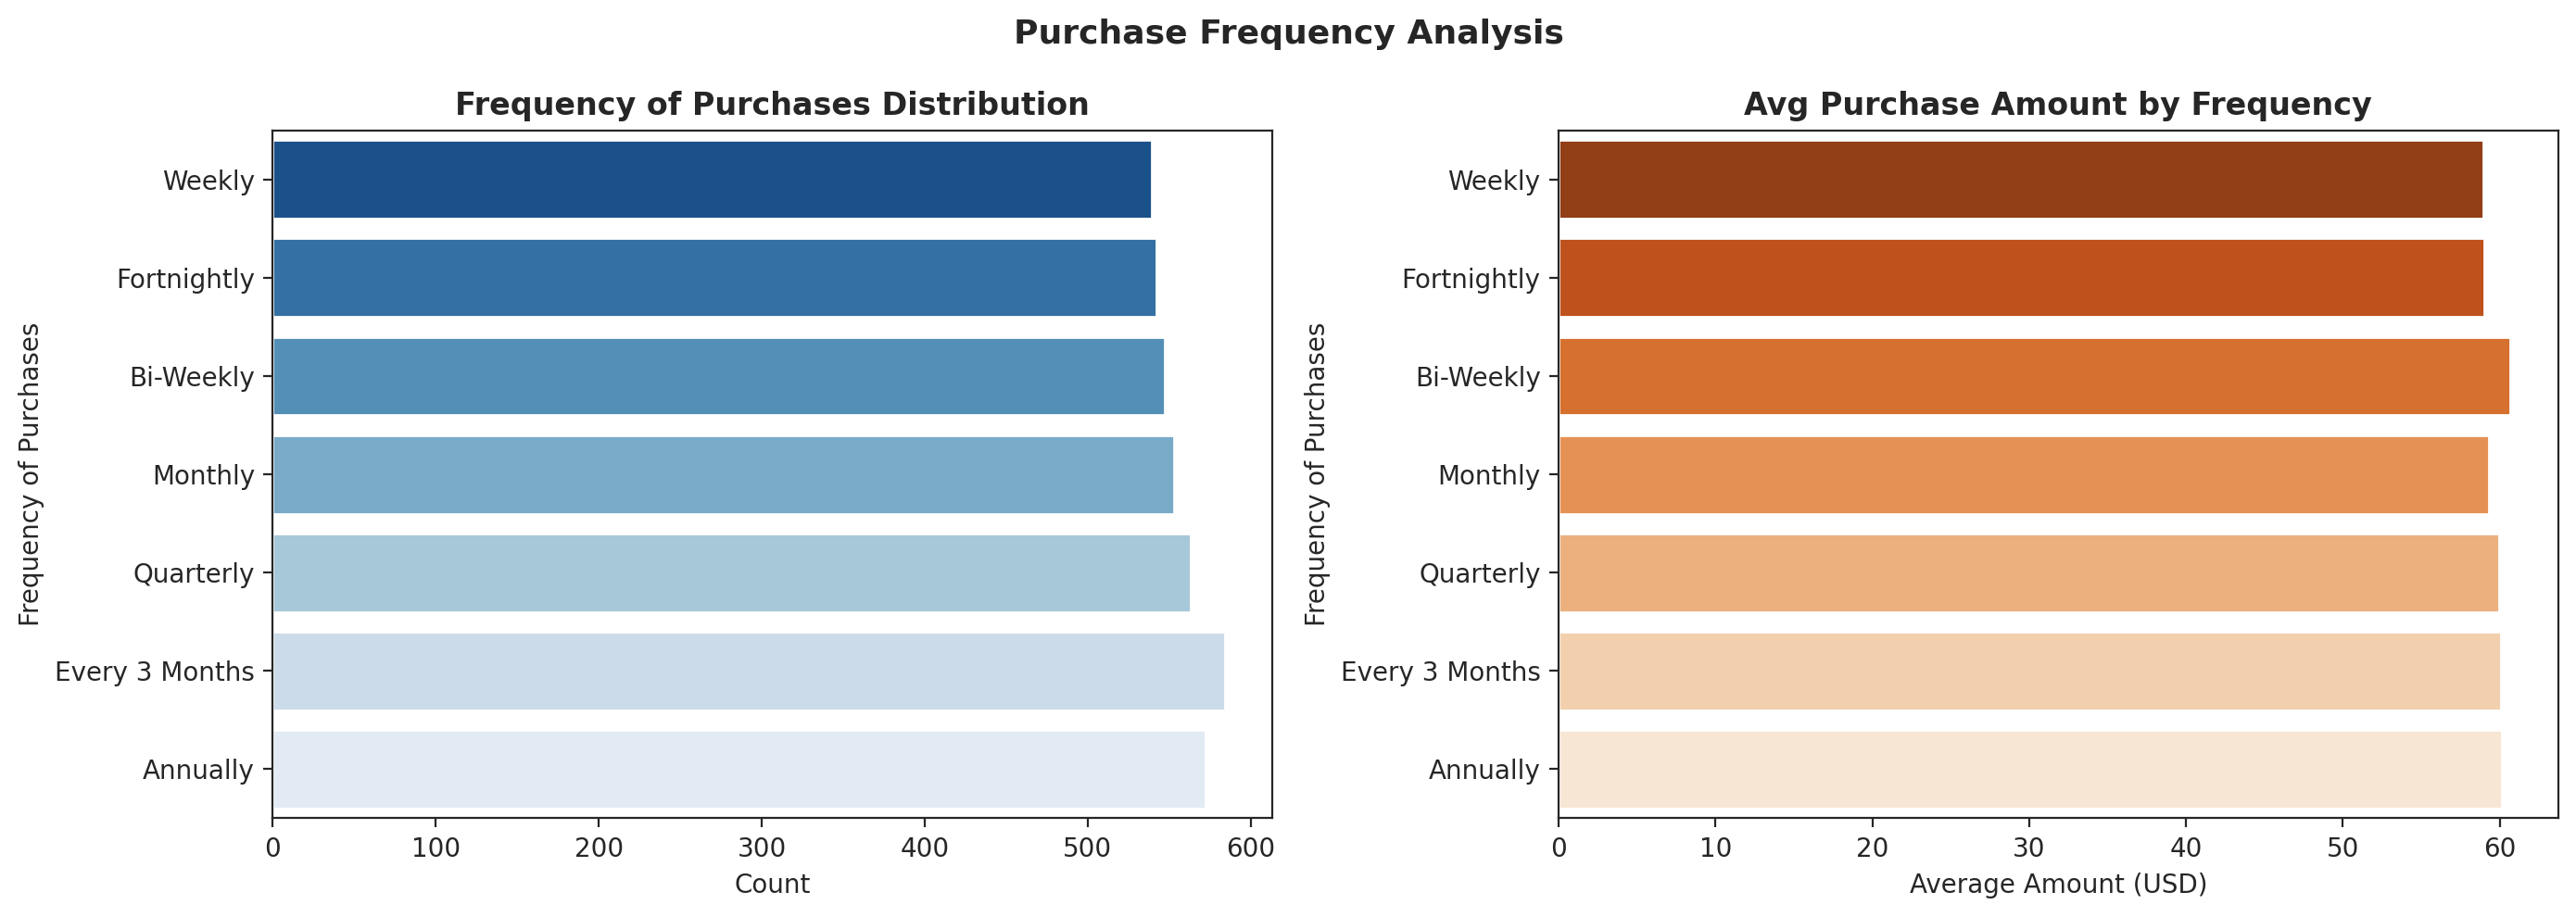

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
freq_order = ['Weekly','Fortnightly','Bi-Weekly','Monthly','Quarterly','Every 3 Months','Annually']
freq_counts = shopping['Frequency of Purchases'].value_counts().reindex(freq_order)
sns.barplot(x=freq_counts.values, y=freq_counts.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Frequency of Purchases Distribution', fontweight='bold')
axes[0].set_xlabel('Count')

freq_amt = shopping .groupby('Frequency of Purchases')['Purchase Amount (USD)'].mean().reindex(freq_order)
sns.barplot(x=freq_amt.values, y=freq_amt.index, palette='Oranges_r', ax=axes[1])
axes[1].set_title('Avg Purchase Amount by Frequency', fontweight='bold')
axes[1].set_xlabel('Average Amount (USD)')
plt.suptitle('Purchase Frequency Analysis', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

Subscription Status vs Discount Applied

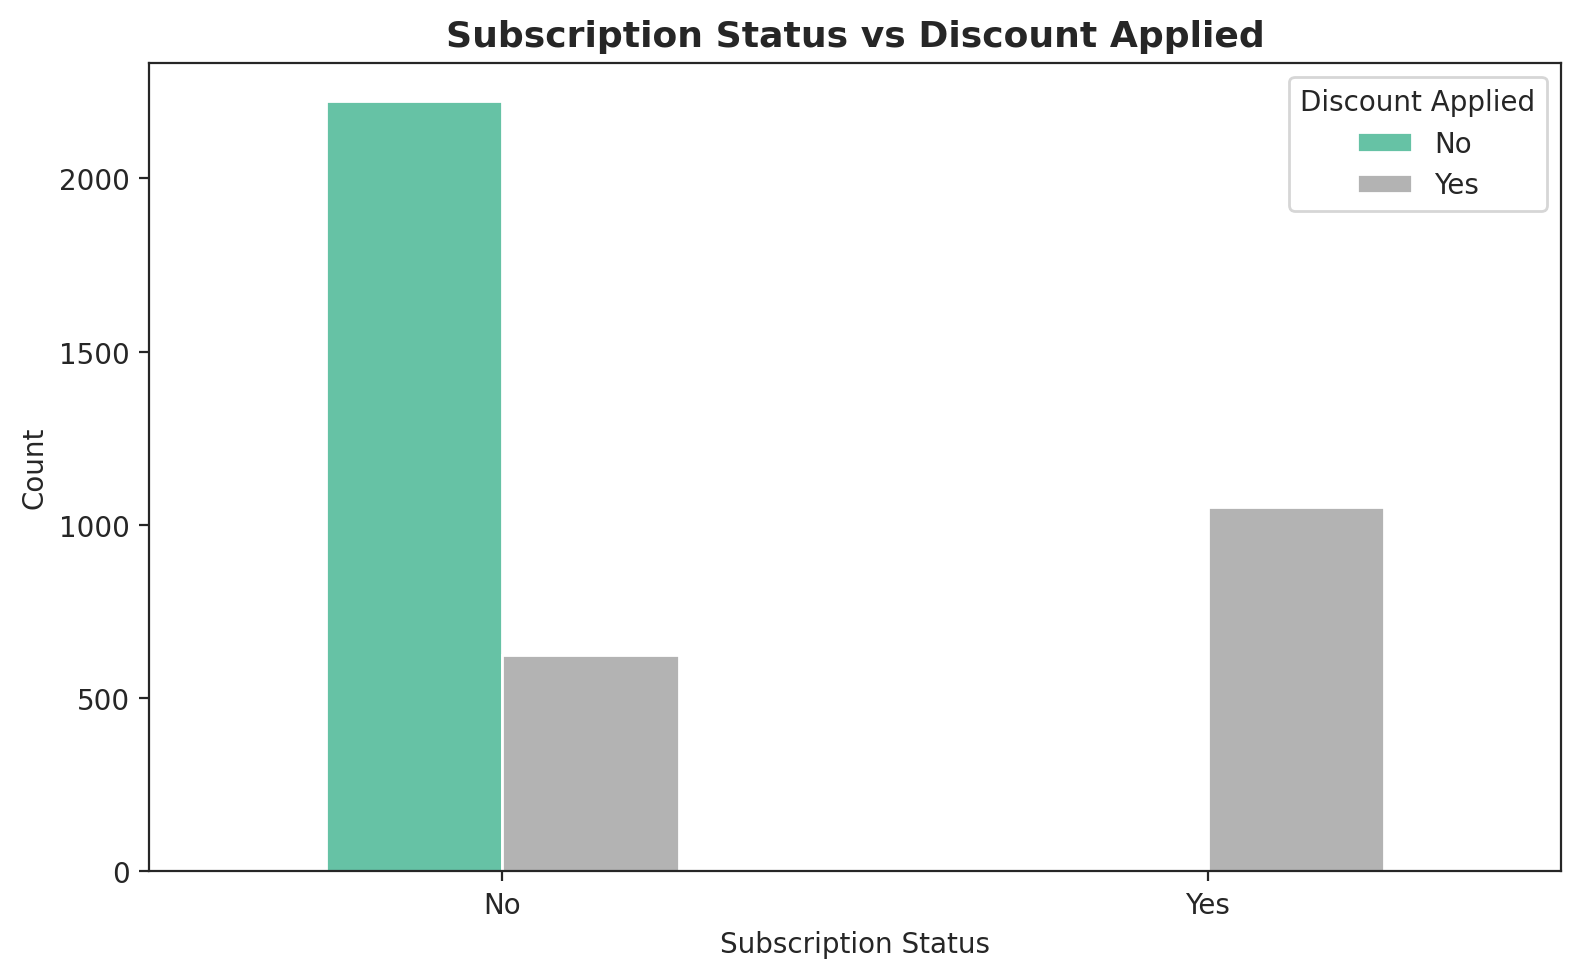

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
cross = pd.crosstab(shopping['Subscription Status'], shopping['Discount Applied'])
cross.plot(kind='bar', ax=ax, colormap=PALETTE, edgecolor='white', rot=0)
ax.set_title('Subscription Status vs Discount Applied', fontweight='bold', fontsize=13)
ax.set_xlabel('Subscription Status'); ax.set_ylabel('Count')
ax.legend(title='Discount Applied')
plt.tight_layout(); plt.show()

 Data Preprocessing and Feature Engineering
Encoding Categorical Variables

In [28]:
shopping_ml = shopping.drop(columns=['Customer ID']).copy()

# Encode binary categorical columns
binary_cols = ['Gender', 'Subscription Status', 'Discount Applied'] # 'Promo Code Used' removed
for col in binary_cols:
    shopping_ml[col] = LabelEncoder().fit_transform(shopping_ml[col])

print("Encoding complete. Sample:")
print(shopping_ml.head())

# Encode multi-class categorical columns
cat_cols = ['Item Purchased','Category','Location','Size','Color',
            'Season','Shipping Type','Payment Method','Frequency of Purchases']
le_dict = {}
for col in cat_cols:
    le_dict[col] = LabelEncoder()
    shopping_ml[col] = le_dict[col].fit_transform(shopping_ml[col])

print("Encoding complete. Sample:")
print(shopping_ml.head())

Encoding complete. Sample:
   Age  Gender Item Purchased  Category  Purchase Amount (USD)       Location  \
0   55       1         Blouse  Clothing                     53       Kentucky   
1   19       1        Sweater  Clothing                     64          Maine   
2   50       1          Jeans  Clothing                     73  Massachusetts   
3   21       1        Sandals  Footwear                     90   Rhode Island   
4   45       1         Blouse  Clothing                     49         Oregon   

  Size      Color  Season  Review Rating  Subscription Status  Shipping Type  \
0    L       Gray  Winter            3.1                    1        Express   
1    L     Maroon  Winter            3.1                    1        Express   
2    S     Maroon  Spring            3.1                    1  Free Shipping   
3    M     Maroon  Spring            3.5                    1   Next Day Air   
4    M  Turquoise  Spring            2.7                    1  Free Shipping   

   Di

In [29]:
from sklearn.preprocessing import LabelEncoder

shopping_ml = shopping.drop(columns=['Customer ID']).copy()

# Encode binary categorical columns
binary_cols = ['Gender', 'Subscription Status', 'Discount Applied'] # Removed 'Promo Code Used'
for col in binary_cols:
    shopping_ml[col] = LabelEncoder().fit_transform(shopping_ml[col])

cat_cols = ['Item Purchased', 'Category', 'Location', 'Size', 'Color',
            'Season', 'Shipping Type', 'Payment Method', 'Frequency of Purchases']
for col in cat_cols:
    shopping_ml[col] = LabelEncoder().fit_transform(shopping_ml[col])

print("Encoding complete. Sample:")
print(shopping_ml.head())

Encoding complete. Sample:
   Age  Gender  Item Purchased  Category  Purchase Amount (USD)  Location  \
0   55       1               2         1                     53        16   
1   19       1              23         1                     64        18   
2   50       1              11         1                     73        20   
3   21       1              14         2                     90        38   
4   45       1               2         1                     49        36   

   Size  Color  Season  Review Rating  Subscription Status  Shipping Type  \
0     0      7       3            3.1                    1              1   
1     0     12       3            3.1                    1              1   
2     2     12       1            3.1                    1              2   
3     1     12       1            3.5                    1              3   
4     1     21       1            2.7                    1              2   

   Discount Applied  Previous Purchases  Paymen

Feature Selection
SelectKBest (F-regression, k=8)

Selected features: ['Category', 'Location', 'Size', 'Season', 'Review Rating', 'Shipping Type', 'Discount Applied', 'Frequency of Purchases']


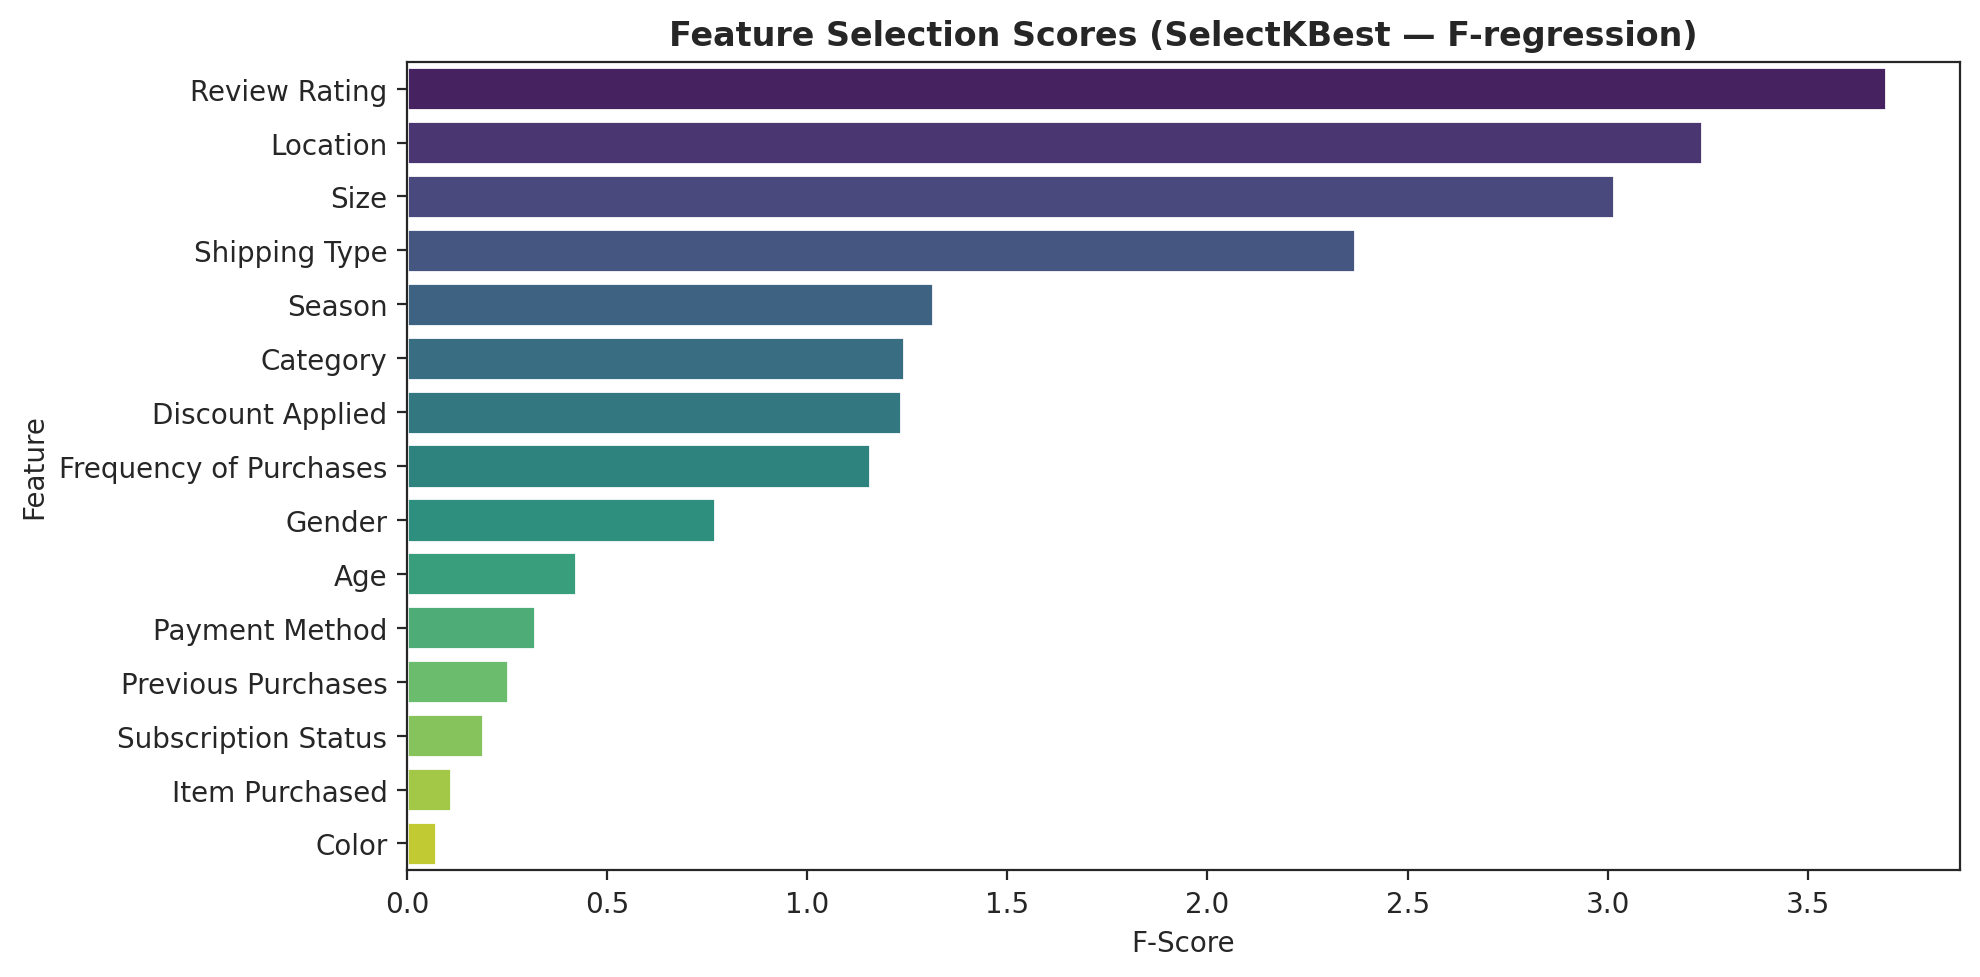

In [30]:
X = shopping_ml.drop(columns=['Purchase Amount (USD)'])
y = shopping_ml['Purchase Amount (USD)']

selector = SelectKBest(f_regression, k=8)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()].tolist()
print("Selected features:", selected_features)

# Visualise feature scores
fig, ax = plt.subplots(figsize=(10, 5))
scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=scores.values, y=scores.index, palette='viridis', ax=ax)
ax.set_title('Feature Selection Scores (SelectKBest — F-regression)', fontweight='bold')
ax.set_xlabel('F-Score'); ax.set_ylabel('Feature')
plt.tight_layout(); plt.show()

Train- Test Split and Scaling

In [31]:
X_sel = X[selected_features]
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set: {X_train_sc.shape}")
print(f"Test set:     {X_test_sc.shape}")

Training set: (3120, 8)
Test set:     (780, 8)


Model Building

In [32]:
lr  = LinearRegression()
rfr = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
gbr = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
ensemble = VotingRegressor([('lr', lr), ('rfr', rfr), ('gbr', gbr)])

models = {
    'Linear Regression':  lr,
    'Random Forest':      rfr,
    'Gradient Boosting':  gbr,
    'Ensemble':           ensemble
}

Lets train the model and evaluate it

In [33]:
Models_results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    cv = cross_val_score(model, X_train_sc, y_train,
                         cv=5, scoring='neg_mean_absolute_error')
    Models_results[name] = {
        'MAE':     mean_absolute_error(y_test, preds),
        'RMSE':    np.sqrt(mean_squared_error(y_test, preds)),
        'R2':      r2_score(y_test, preds),
        'CV_mean': -cv.mean(),
        'CV_std':   cv.std(),
        'preds':   preds
    }
    print(f"{name}: MAE={Models_results[name]['MAE']:.4f}  "
          f"RMSE={Models_results[name]['RMSE']:.4f}  "
          f"R2={Models_results[name]['R2']:.4f}  "
          f"CV={Models_results[name]['CV_mean']:.4f}±{Models_results[name]['CV_std']:.4f}")

Linear Regression: MAE=20.7558  RMSE=23.7409  R2=-0.0072  CV=20.5385±0.4327
Random Forest: MAE=20.8447  RMSE=23.7957  R2=-0.0119  CV=20.6642±0.4547
Gradient Boosting: MAE=21.0677  RMSE=24.0705  R2=-0.0354  CV=20.7232±0.4638
Ensemble: MAE=20.8344  RMSE=23.7735  R2=-0.0100  CV=20.5770±0.4600


Model Evaluation

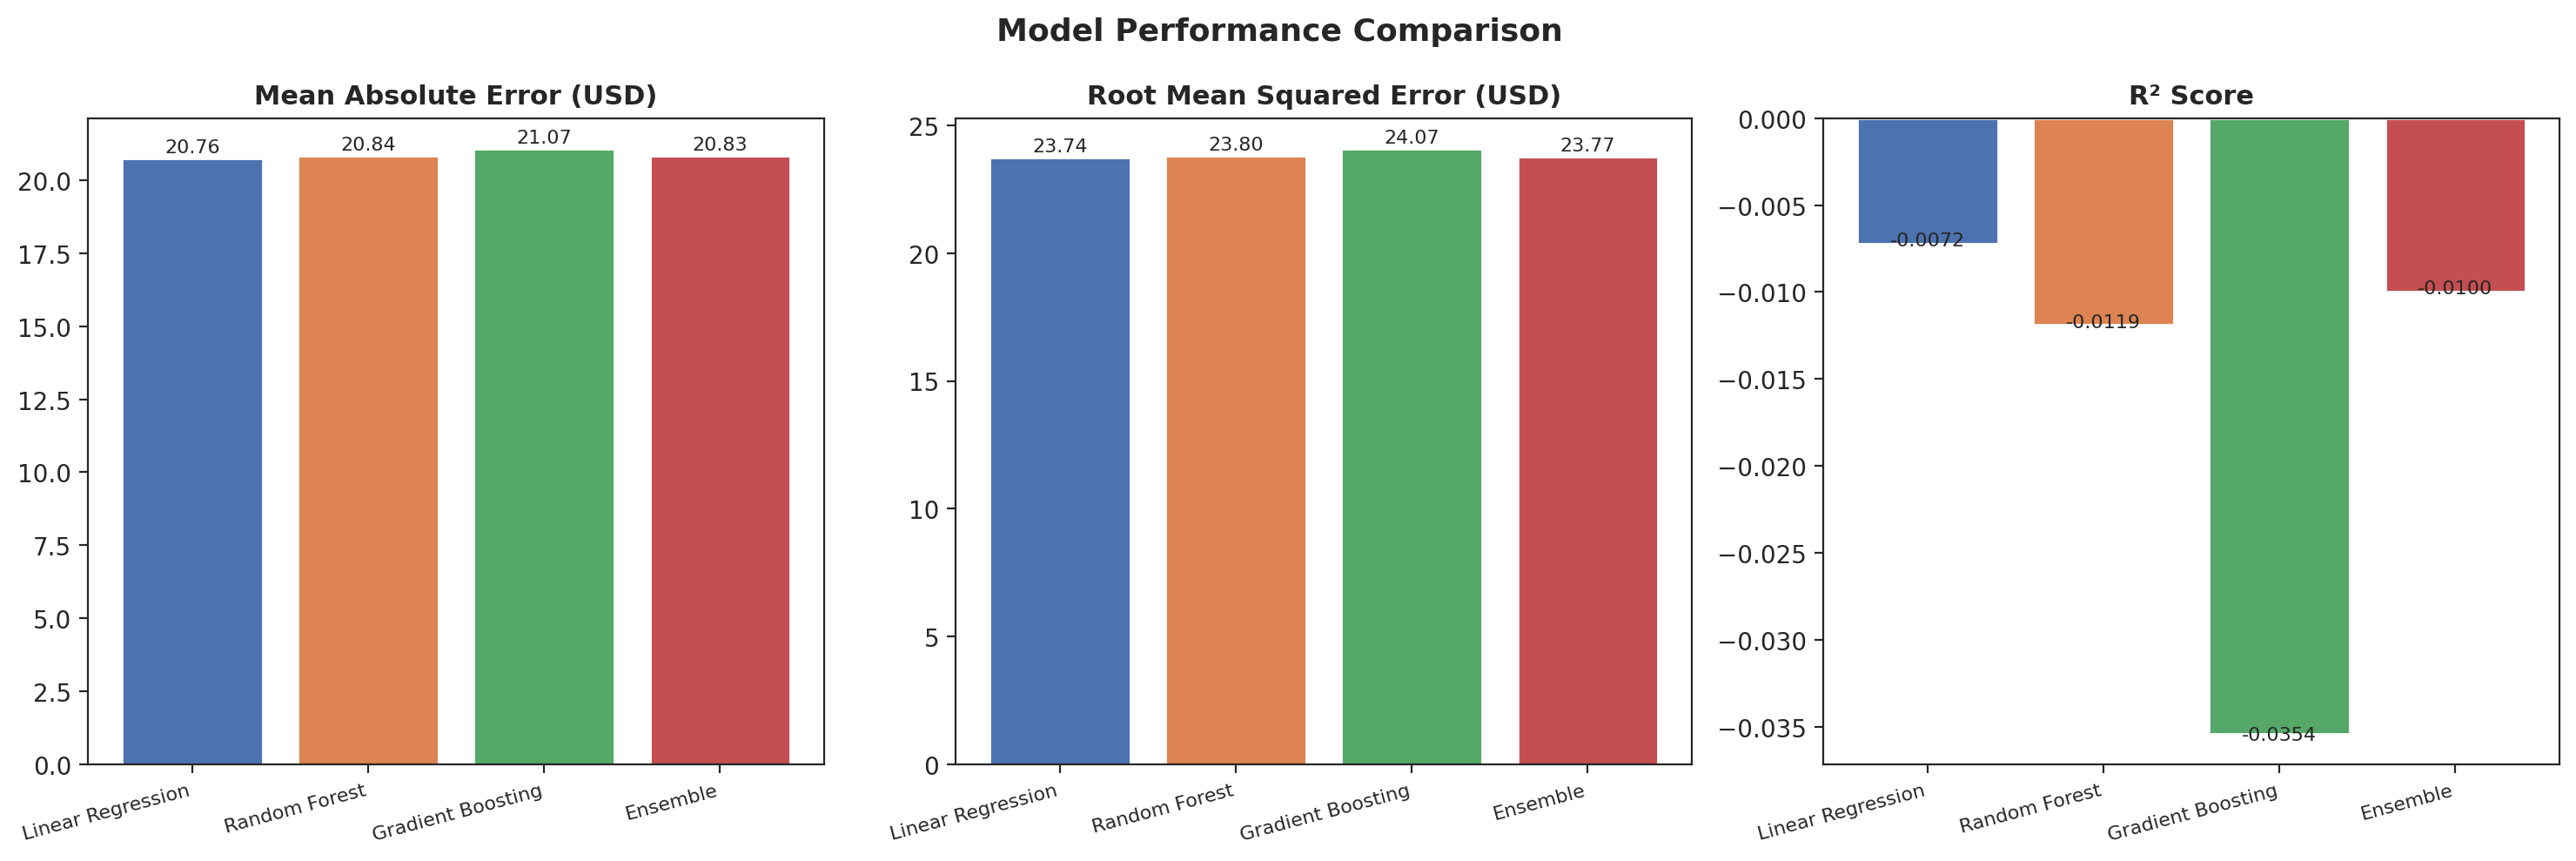

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
for i, (metric, label) in enumerate(zip(
        ['MAE','RMSE','R2'],
        ['Mean Absolute Error (USD)','Root Mean Squared Error (USD)','R² Score'])):
    vals = [Models_results[m][metric] for m in Models_results]
    bars = axes[i].bar(list(Models_results.keys()), vals, color=colors, edgecolor='white')
    axes[i].set_title(label, fontweight='bold', fontsize=11)
    axes[i].set_xticklabels(list(Models_results.keys()), rotation=15, ha='right', fontsize=8)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                     f'{v:.2f}' if metric != 'R2' else f'{v:.4f}',
                     ha='center', fontsize=8)
plt.suptitle('Model Performance Comparison', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

Actual and predicted

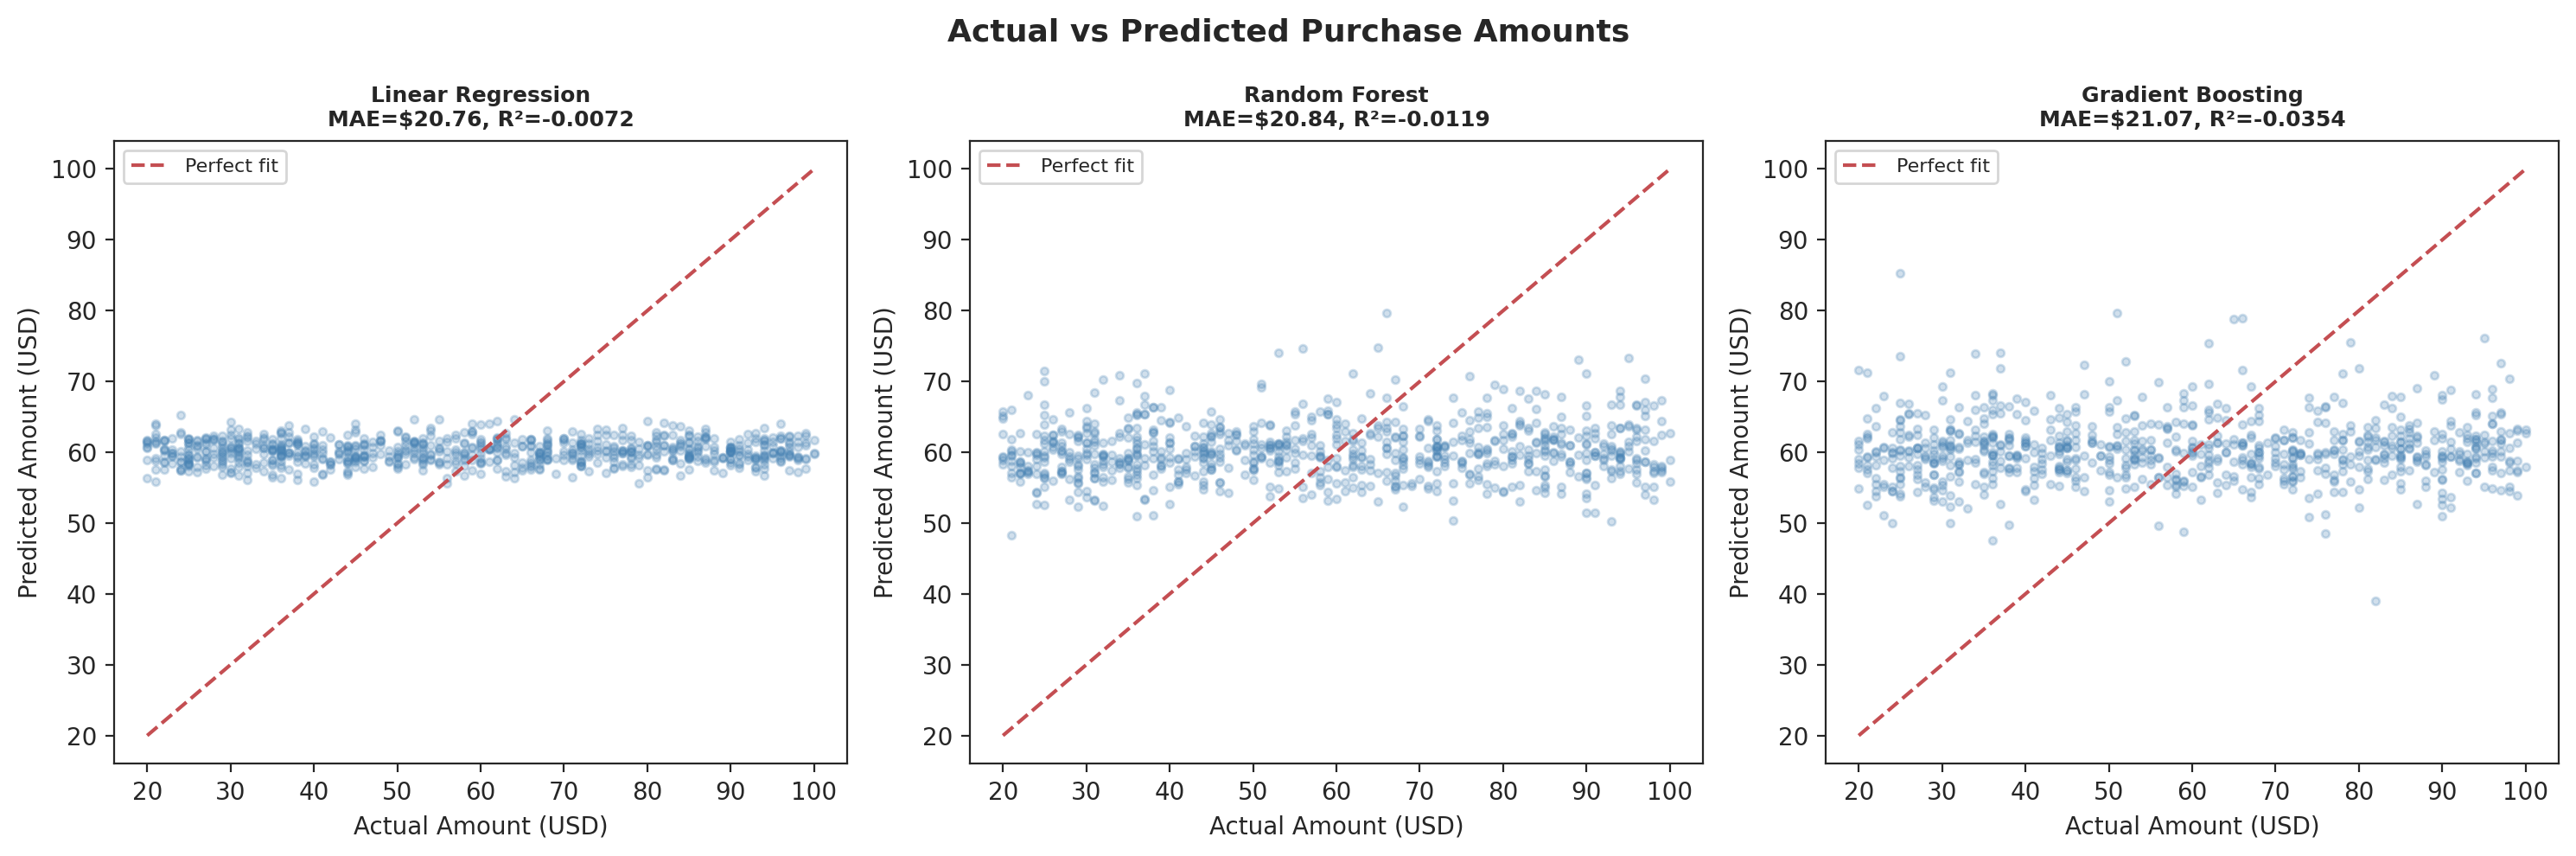

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, mname in zip(axes, ['Linear Regression','Random Forest','Gradient Boosting']):
    preds = Models_results[mname]['preds']
    ax.scatter(y_test, preds, alpha=0.25, s=10, color='steelblue')
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
    ax.set_title(f'{mname}\nMAE=${Models_results[mname]["MAE"]:.2f}, R²={Models_results[mname]["R2"]:.4f}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Actual Amount (USD)'); ax.set_ylabel('Predicted Amount (USD)')
    ax.legend(fontsize=8)
plt.suptitle('Actual vs Predicted Purchase Amounts', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

Cross Validation

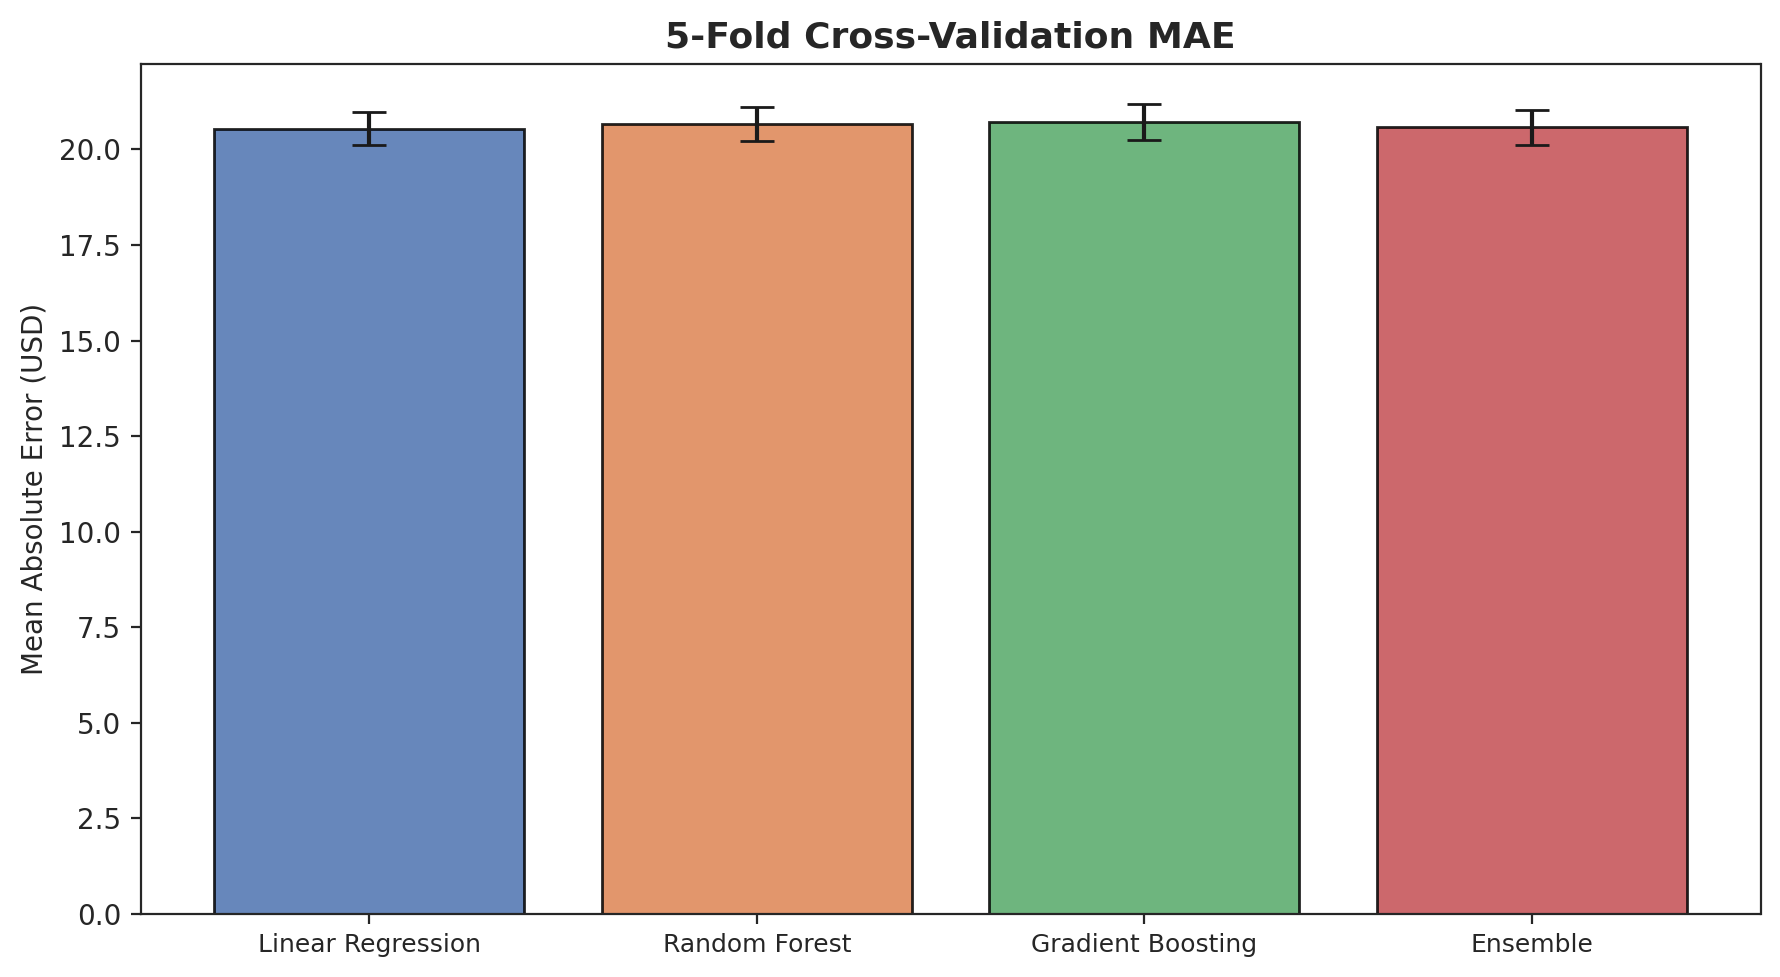

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))
cv_means = [Models_results[m]['CV_mean'] for m in Models_results]
cv_stds  = [Models_results[m]['CV_std']  for m in Models_results]
ax.bar(np.arange(4), cv_means, yerr=cv_stds, capsize=6,
       color=colors, alpha=0.85, edgecolor='black')
ax.set_xticks(np.arange(4))
ax.set_xticklabels(list(Models_results.keys()), fontsize=9)
ax.set_title('5-Fold Cross-Validation MAE', fontweight='bold', fontsize=13)
ax.set_ylabel('Mean Absolute Error (USD)')
plt.tight_layout(); plt.show()

Feature Coefficients - Linear Regression

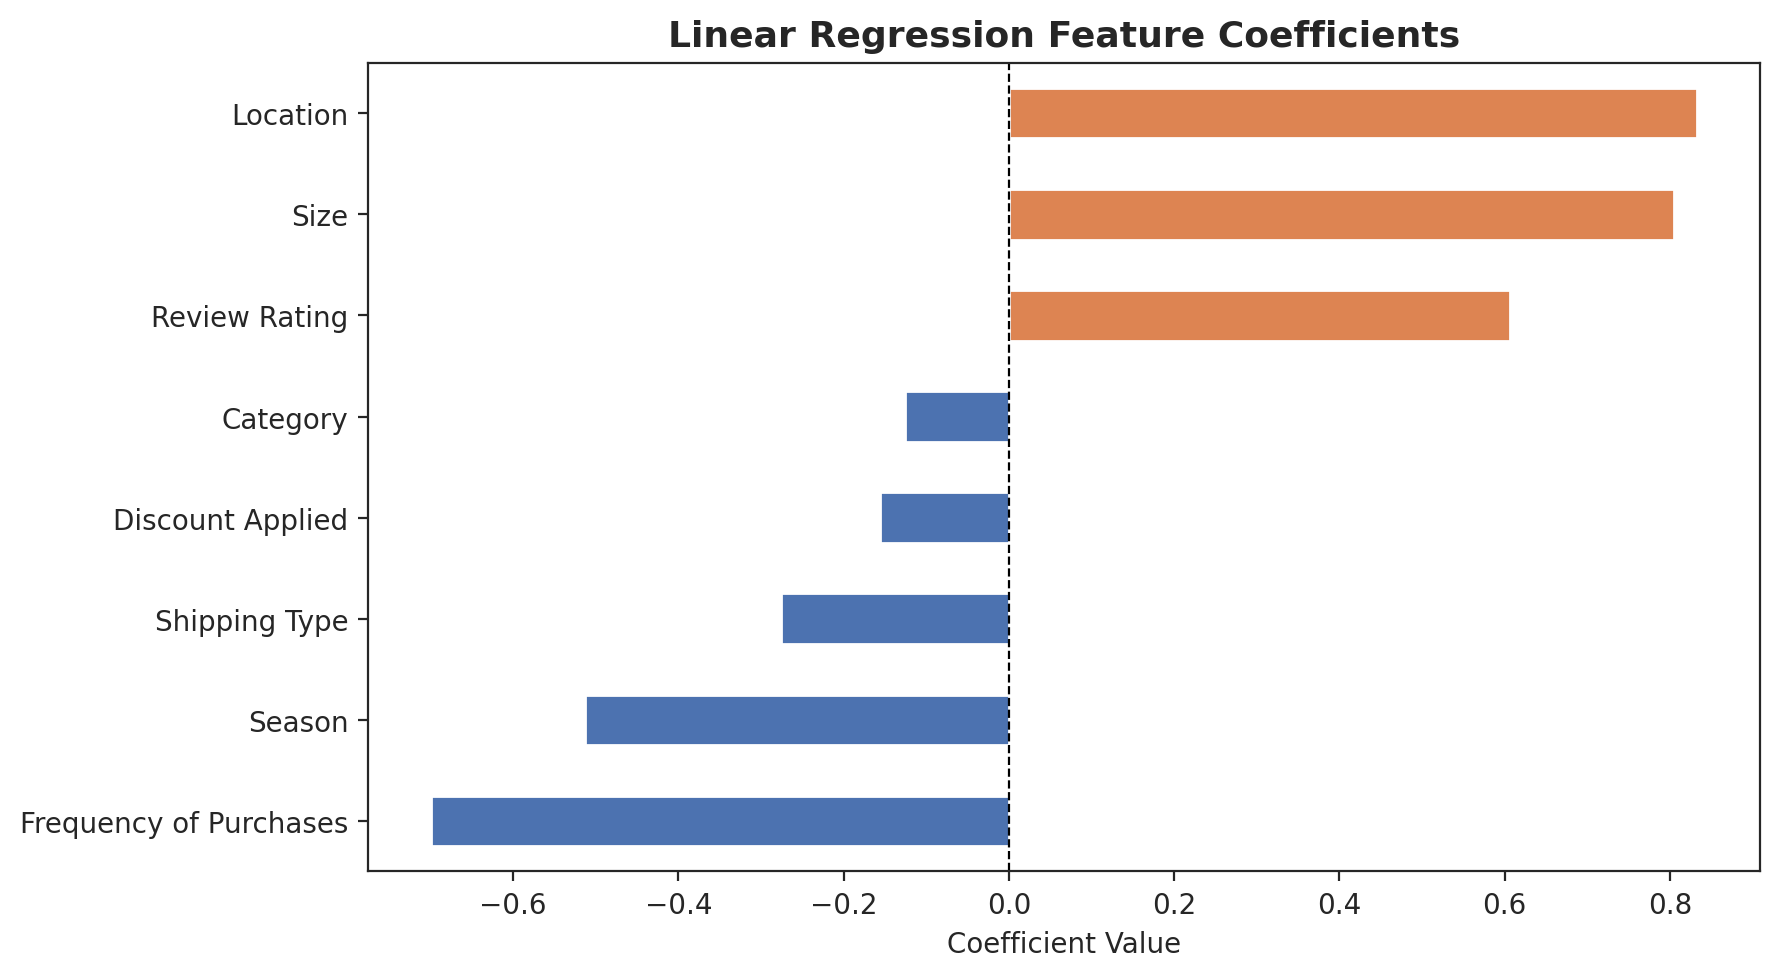

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
coef = pd.Series(lr.coef_, index=selected_features).sort_values()
coef.plot(kind='barh',
          color=['#DD8452' if c > 0 else '#4C72B0' for c in coef], ax=ax)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Linear Regression Feature Coefficients', fontweight='bold', fontsize=13)
ax.set_xlabel('Coefficient Value')
plt.tight_layout(); plt.show()


 Global and Local Explanations with SHAP
SHAP Feature Importance (Global)


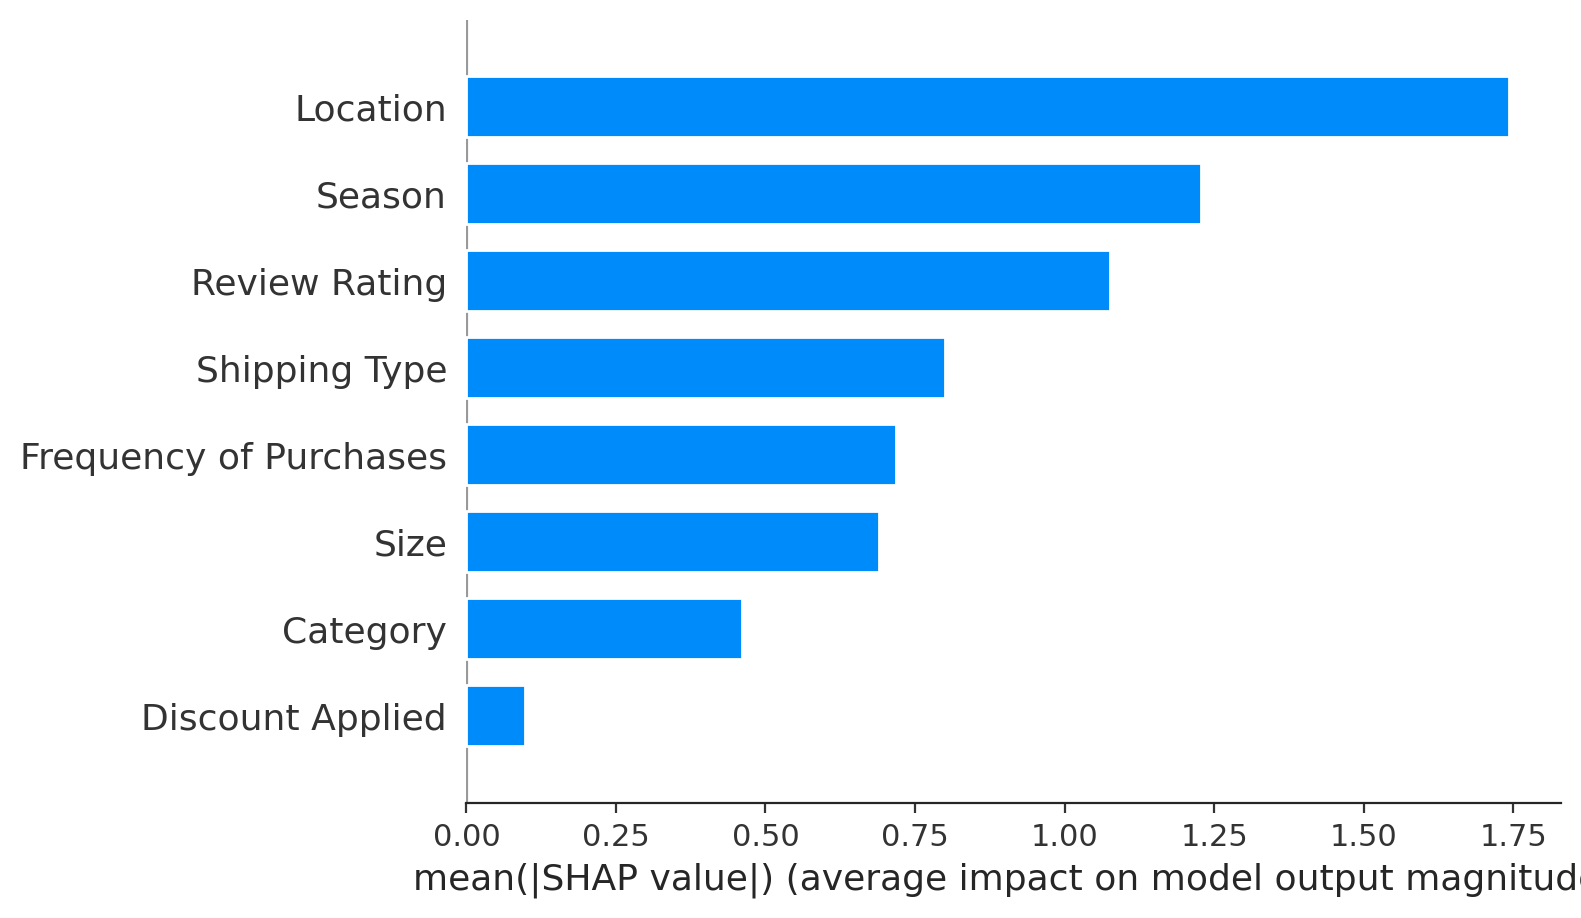

In [38]:
explainer  = shap.TreeExplainer(gbr)
shap_values = explainer.shap_values(X_test_sc)

shap.summary_plot(shap_values, X_test_sc,
                  feature_names=selected_features, plot_type='bar')

Partial Dependency Plots (PDP)

Top 2 features for PDP: ['Location', 'Season']


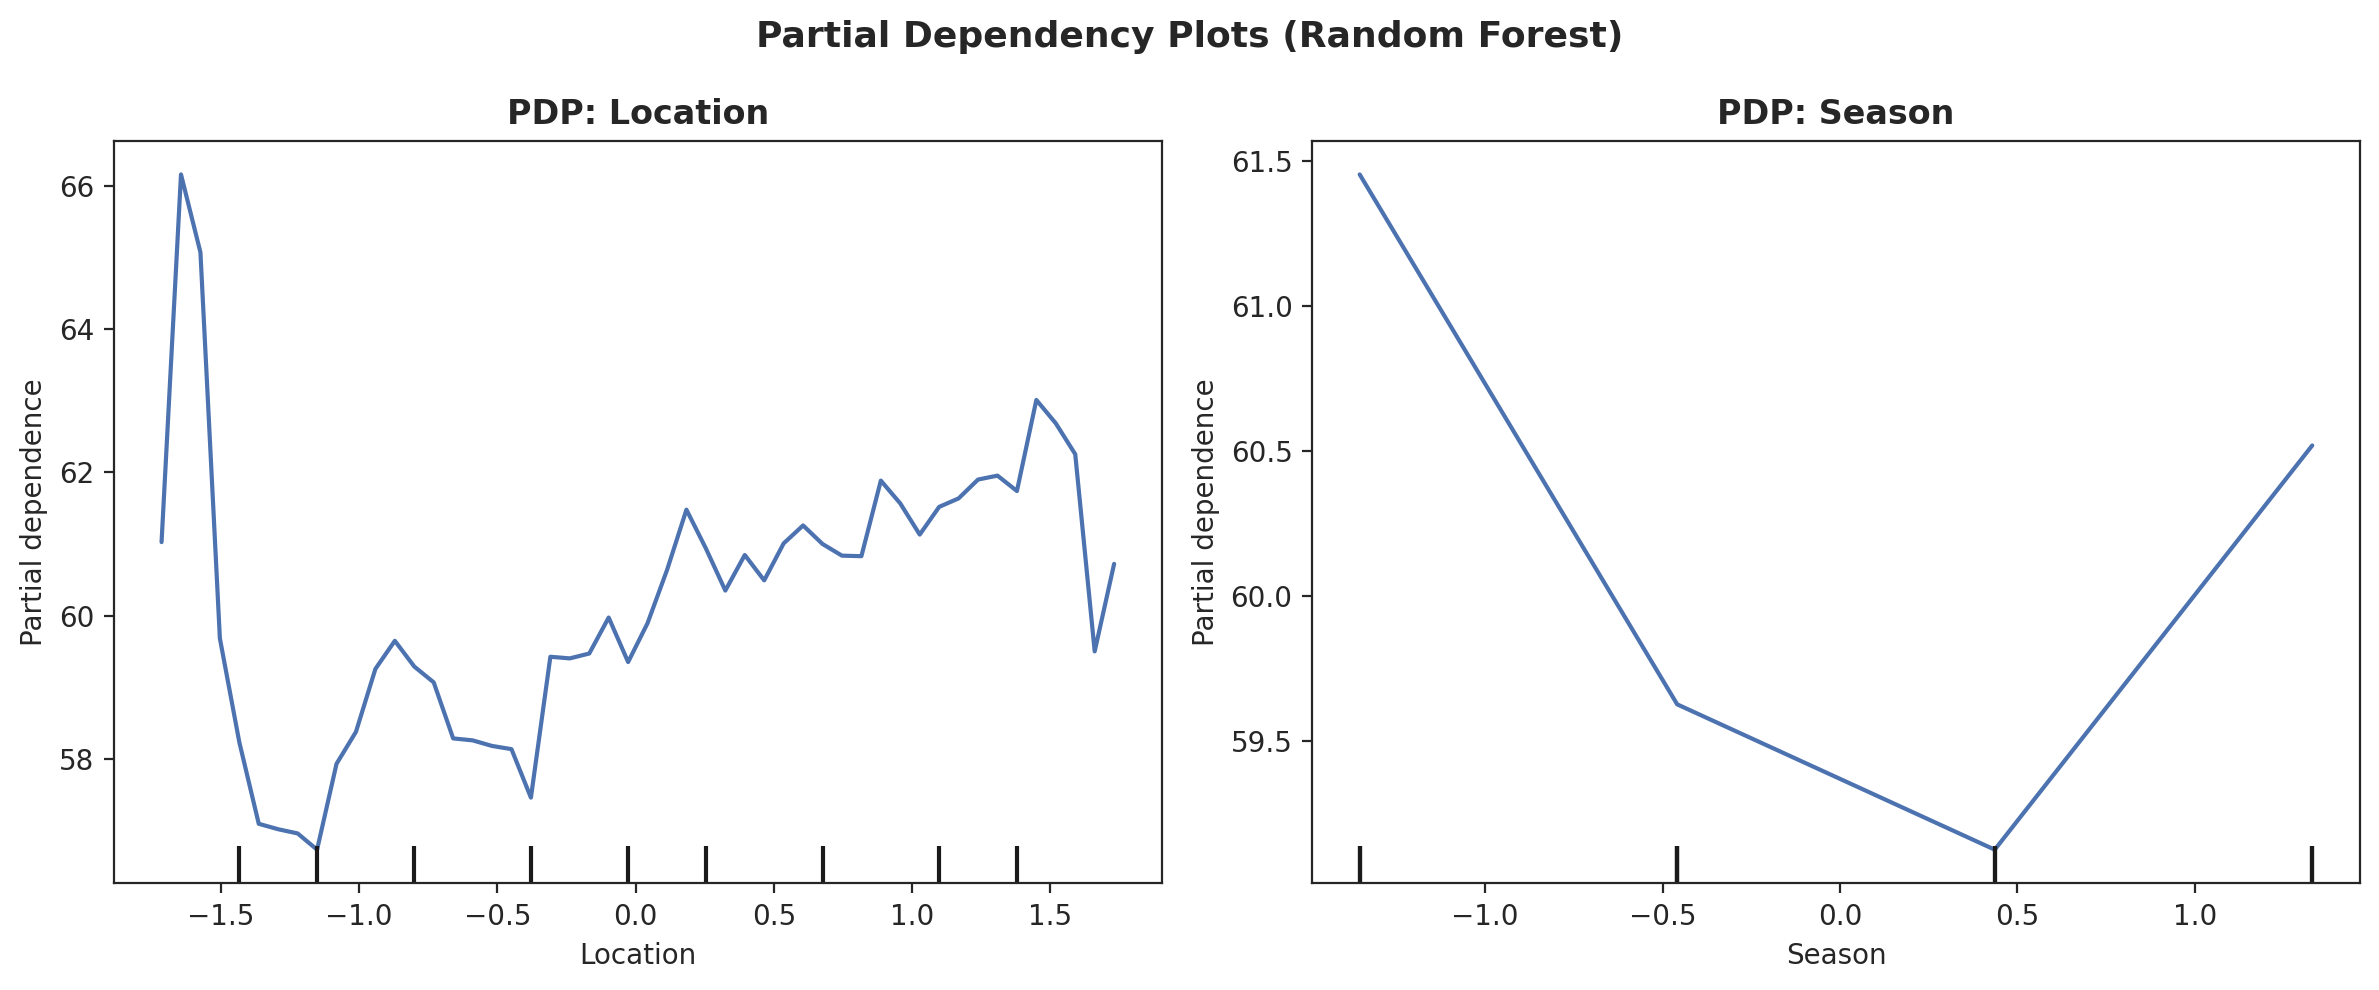

In [39]:
shap_imp = pd.Series(np.abs(shap_values).mean(axis=0),
                     index=selected_features).sort_values(ascending=False)
top2 = shap_imp.index[:2].tolist()
top2_idx = [selected_features.index(f) for f in top2]
print("Top 2 features for PDP:", top2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
PartialDependenceDisplay.from_estimator(rfr, X_test_sc,
    [top2_idx[0]], feature_names=selected_features, ax=axes[0])
axes[0].set_title(f'PDP: {top2[0]}', fontweight='bold')

PartialDependenceDisplay.from_estimator(rfr, X_test_sc,
    [top2_idx[1]], feature_names=selected_features, ax=axes[1])
axes[1].set_title(f'PDP: {top2[1]}', fontweight='bold')
plt.suptitle('Partial Dependency Plots (Random Forest)', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

The analysis reveals that purchase amount in this dataset is essentially uniformly distributed between 20 and 100, resulting in near-zero R² scores across all models. This is a meaningful finding: no combination of demographic, behavioural, or transactional features reliably predicts how much a customer spends per transaction. The key drivers of shopping behaviour identified through EDA and SHAP are seasonal variation, location, discount/promo usage, and shipping preference — but these influence what customers buy more than how much they spend.